# Chapitre 3 : Préparation et Analyse des Données

> **Projet de Fin d'Études — Ingénierie Informatique**
> *Système Intelligent d'Analyse Prédictive et de Détection des Comportements Suspects dans les Données de Consommation d'Eau et d'Électricité — Intégration de l'Explainable AI et de Power BI*


---

Ce chapitre constitue le socle expérimental du projet. Avant toute modélisation, la qualité et la pertinence des données conditionnent directement la fiabilité des modèles prédictifs et de détection de fraude. Nous y présentons l'ensemble du pipeline de **data engineering** : compréhension métier du jeu de données, audit de qualité, nettoyage, transformation, *feature engineering*, traitement du déséquilibre des classes, analyse exploratoire (EDA) approfondie, puis sélection des variables aboutissant à un jeu de données final prêt pour la phase de modélisation du Chapitre 4.

La démarche suit le standard industriel **CRISP-DM** (Cross-Industry Standard Process for Data Mining), en se concentrant sur les phases *Data Understanding* et *Data Preparation*.

## 3.1 Présentation du Dataset

### 3.1.1 Description du dataset

Le jeu de données provient du système de gestion des relevés de la **Société Régionale Multiservices (SRM) Rabat-Salé-Kénitra**, opérateur en charge de la distribution d'eau potable et d'électricité dans la région. Chaque enregistrement correspond à un **relevé mensuel de compteur** pour un client donné, accompagné des informations contractuelles, géographiques et de facturation associées, ainsi que d'indicateurs d'anomalie produits par le système d'information.

Le périmètre temporel couvre **seize années de relevés mensuels (2010 – 2025)**, ce qui offre une profondeur historique suffisante pour analyser la saisonnalité, les tendances de long terme et les comportements atypiques.

### 3.1.2 Analyse métier des données

Sur le plan métier, ce jeu de données répond à trois enjeux stratégiques pour un distributeur :

1. **La prévision de la consommation** — anticiper la demande en eau et en électricité par zone et par profil client.
2. **La détection des pertes non-techniques (NTL)** — identifier les fraudes (manipulation de compteur, branchement illicite, contournement) qui représentent une perte financière directe.
3. **La connaissance client** — segmenter les abonnés selon leur comportement de consommation et de paiement.

La variable cible de ce chapitre, `SuspectFlag`, matérialise le second enjeu : elle indique si un relevé est jugé suspect (fraude potentielle) ou normal.

**Enjeu financier.** Les pertes non-techniques (fraude, branchements illicites, compteurs trafiqués) pèsent lourdement sur la rentabilité des distributeurs d'eau et d'électricité, en particulier en Afrique : selon les analyses sectorielles, la fraude peut représenter jusqu'à environ 20 % des pertes non-techniques d'un opérateur, elles-mêmes largement supérieures aux pertes techniques dans les réseaux les moins automatisés. Pour une société comme la SRM, chaque point de pourcentage de fraude non détectée se traduit directement par une perte de chiffre d'affaires et par un besoin accru d'investissement en contrôle terrain. C'est ce problème de gestion — détecter la fraude au moindre coût, sans multiplier les contrôles inutiles — que ce chapitre prépare à résoudre.

In [1]:
# --- Importation des bibliothèques fondamentales pour l'exploration initiale ---
import pandas as pd
import numpy as np

# Options d'affichage pour une lecture confortable des tableaux
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# --- Chargement du dataset ---
import os
CANDIDATS = ['dataset_srm_realistic.xlsx',
             '/mnt/user-data/uploads/dataset_srm_realistic.xlsx',
             'data/dataset_srm_PFE.xlsx']
DATA_PATH = next((p for p in CANDIDATS if os.path.exists(p)), CANDIDATS[0])
print(f"Lecture du fichier : {DATA_PATH}")

df = pd.read_excel(DATA_PATH)
print(f"Dataset chargé avec succès — {df.shape[0]:,} lignes et {df.shape[1]} colonnes.")

Lecture du fichier : dataset_srm_realistic.xlsx
Dataset chargé avec succès — 50,311 lignes et 15 colonnes.


**Affichage des premières lignes** pour une première inspection visuelle de la structure et du contenu.

In [2]:
# Aperçu des cinq premiers relevés
df.head()

,CustomerID,TypeService,TypeClient,Province,Ville,Quartier,Mois,IndexPrecedent,IndexActuel,Consommation,MontantFacture,StatutPaiement,AnomalyScore,SuspectFlag,TypeSuspect
0,C001973,Électricité,Particulier,Khémisset,Oulmès,Oulmès,2023-02,"86,838.26","86,926.93",88.67,127.59,Impayé,0.29,0,Aucune
1,C000162,Électricité,Particulier,Kénitra,Mehdia,Mehdia,2011-02,"49,027.36","49,125.21",97.85,167.89,Payé,0.22,0,Aucune
2,C000729,Eau,Particulier,Salé,Shoul,Shoul,2019-10,"68,410.90","68,431.55",20.65,164.83,Payé,0.08,0,Aucune
3,C001555,Eau,Particulier,Skhirate-Témara,Témara,Massira,2016-05,"7,716.52","7,743.43",-26.91,204.25,En retard,0.16,0,Aucune
4,C000816,Électricité,Particulier,Kénitra,Mnasra,Mnasra,2015-01,"199,673.86","199,878.92",205.06,277.64,Payé,0.20,0,Aucune


### 3.1.3 Dimensions et description des variables

In [3]:
# Dimensions exactes du jeu de données
n_lignes, n_colonnes = df.shape
print(f"Nombre de lignes  (observations) : {n_lignes:,}")
print(f"Nombre de colonnes (variables)   : {n_colonnes}")
print(f"Empreinte mémoire                : {df.memory_usage(deep=True).sum() / 1e6:,.1f} Mo")

Nombre de lignes  (observations) : 50,311
Nombre de colonnes (variables)   : 15
Empreinte mémoire                : 29.8 Mo


In [4]:
# --- Dictionnaire des données : description métier de chaque variable ---
dictionnaire = pd.DataFrame([
    ("CustomerID",     "Catégorielle", "Identifiant unique de l'abonné"),
    ("TypeService",    "Catégorielle", "Service concerné : Eau ou Électricité"),
    ("TypeClient",     "Catégorielle", "Segment du client : Particulier, Commerce, Industrie, Administration"),
    ("Province",       "Catégorielle", "Province / préfecture (7) de la région Rabat-Salé-Kénitra"),
    ("Ville",          "Catégorielle", "Ville du point de livraison"),
    ("Quartier",       "Catégorielle", "Quartier / commune du point de livraison"),
    ("Mois",           "Temporelle",   "Période du relevé au format AAAA-MM"),
    ("IndexPrecedent", "Numérique",    "Index du compteur au relevé précédent"),
    ("IndexActuel",    "Numérique",    "Index du compteur au relevé courant"),
    ("Consommation",   "Numérique",    "Consommation de la période (IndexActuel - IndexPrecedent)"),
    ("MontantFacture", "Numérique",    "Montant facturé pour la période (en MAD)"),
    ("StatutPaiement", "Catégorielle", "État du règlement : Payé, Impayé, En retard"),
    ("AnomalyScore",   "Numérique",    "Score d'anomalie [0–1] issu du SI (plus élevé = plus suspect)"),
    ("SuspectFlag",    "Cible (binaire)", "1 = relevé suspect (fraude potentielle), 0 = normal"),
    ("TypeSuspect",    "Catégorielle", "Nature de la fraude détectée (Aucune si normal)"),
], columns=["Variable", "Type", "Description métier"])

dictionnaire

,Variable,Type,Description métier
0,CustomerID,Catégorielle,Identifiant unique de l'abonné
1,TypeService,Catégorielle,Service concerné : Eau ou Électricité
2,TypeClient,Catégorielle,"Segment du client : Particulier, Commerce, Ind..."
3,Province,Catégorielle,Province / préfecture (7) de la région Rabat-S...
4,Ville,Catégorielle,Ville du point de livraison
5,Quartier,Catégorielle,Quartier / commune du point de livraison
6,Mois,Temporelle,Période du relevé au format AAAA-MM
7,IndexPrecedent,Numérique,Index du compteur au relevé précédent
8,IndexActuel,Numérique,Index du compteur au relevé courant
9,Consommation,Numérique,Consommation de la période (IndexActuel - Inde...


In [5]:
# Structure technique : types de données et taux de remplissage par colonne
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50311 entries, 0 to 50310
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      50311 non-null  object 
 1   TypeService     50311 non-null  object 
 2   TypeClient      49708 non-null  object 
 3   Province        50060 non-null  object 
 4   Ville           49808 non-null  object 
 5   Quartier        49406 non-null  object 
 6   Mois            50311 non-null  object 
 7   IndexPrecedent  48802 non-null  float64
 8   IndexActuel     49054 non-null  float64
 9   Consommation    49307 non-null  float64
 10  MontantFacture  49557 non-null  float64
 11  StatutPaiement  49205 non-null  object 
 12  AnomalyScore    48556 non-null  float64
 13  SuspectFlag     50311 non-null  int64  
 14  TypeSuspect     50011 non-null  object 
dtypes: float64(5), int64(1), object(9)
memory usage: 5.8+ MB


## 3.2 Préparation des Données

La préparation des données est l'étape la plus déterminante d'un projet de *data science* : elle représente couramment 70 à 80 % de la charge de travail. Un modèle, aussi sophistiqué soit-il, ne peut compenser des données erronées (*garbage in, garbage out*). Nous procédons en cinq temps : chargement, audit de qualité, nettoyage, transformation et *feature engineering*.

### 3.2.1 Chargement des données

Les bibliothèques nécessaires à l'ensemble du chapitre sont importées ci-dessous et regroupées pour la lisibilité.

In [6]:
# --- Bibliothèques de manipulation et calcul numérique ---
import pandas as pd
import numpy as np

# --- Visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Prétraitement et apprentissage (scikit-learn) ---
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             average_precision_score, precision_recall_curve,
                             classification_report, confusion_matrix)

# --- Rééchantillonnage (imbalanced-learn) ---
from imblearn.over_sampling import RandomOverSampler, SMOTE, SMOTENC
from imblearn.under_sampling import RandomUnderSampler

# --- Gradient boosting ---
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# --- Configuration graphique homogène pour tout le chapitre ---
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42  # graine fixe : garantit la reproductibilité des résultats
np.random.seed(RANDOM_STATE)

# --- Traçabilité de l'environnement (reproductibilité) ---
import sklearn, imblearn, xgboost, sys
print("Environnement et bibliothèques chargés avec succès.")
print(f"Python      : {sys.version.split()[0]}")
print(f"pandas      : {pd.__version__}")
print(f"numpy       : {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"imbalanced-learn: {imblearn.__version__}")
print(f"xgboost     : {xgboost.__version__}")
print(f"RANDOM_STATE fixé à {RANDOM_STATE} pour l'ensemble du chapitre.")

Environnement et bibliothèques chargés avec succès.
Python      : 3.13.5
pandas      : 2.2.3
numpy       : 2.1.3
scikit-learn: 1.6.1
imbalanced-learn: 0.13.0
xgboost     : 3.3.0
RANDOM_STATE fixé à 42 pour l'ensemble du chapitre.


### 3.2.2 Audit de qualité des données

Avant tout nettoyage, nous réalisons un diagnostic complet afin d'objectiver les défauts du jeu de données. Cet audit porte sur cinq dimensions de la qualité : **types de données, valeurs manquantes, doublons, incohérences métier et valeurs aberrantes (*outliers*)**.

#### a) Vérification des types de données

In [7]:
# Récapitulatif des types détectés par pandas
types_resume = (df.dtypes.astype(str)
                .value_counts()
                .rename_axis('Type détecté')
                .reset_index(name='Nombre de colonnes'))
print(types_resume.to_string(index=False))
print()
# Détail colonne par colonne
df.dtypes.to_frame('dtype')

Type détecté  Nombre de colonnes
      object                   9
     float64                   5
       int64                   1



,dtype
CustomerID,object
TypeService,object
TypeClient,object
Province,object
Ville,object
Quartier,object
Mois,object
IndexPrecedent,float64
IndexActuel,float64
Consommation,float64


**Interprétation.** La colonne `Mois` est stockée en texte (`object`) alors qu'elle représente une information temporelle : elle devra être convertie en `datetime`. Les variables numériques (`IndexPrecedent`, `IndexActuel`, `Consommation`, `MontantFacture`, `AnomalyScore`) sont bien typées en flottants, et `SuspectFlag` en entier — ce qui est cohérent avec une cible binaire.

#### b) Valeurs manquantes

In [8]:
# Comptage et pourcentage de valeurs manquantes par colonne
manquantes = pd.DataFrame({
    'Nb manquants': df.isnull().sum(),
    '% manquants': (df.isnull().mean() * 100).round(2)
})
manquantes = manquantes[manquantes['Nb manquants'] > 0].sort_values('% manquants', ascending=False)
manquantes

,Nb manquants,% manquants
AnomalyScore,1755,3.49
IndexPrecedent,1509,3.00
IndexActuel,1257,2.50
StatutPaiement,1106,2.20
Consommation,1004,2.00
Quartier,905,1.80
MontantFacture,754,1.50
TypeClient,603,1.20
Ville,503,1.00
TypeSuspect,300,0.60


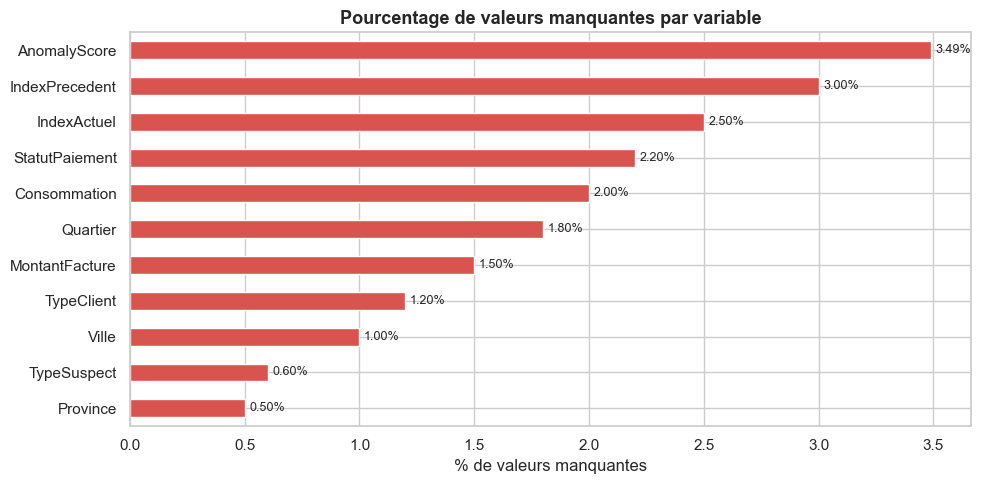

In [9]:
# Visualisation : volume de valeurs manquantes par variable
fig, ax = plt.subplots(figsize=(10, 5))
manquantes['% manquants'].sort_values().plot(kind='barh', ax=ax, color='#d9534f')
ax.set_title("Pourcentage de valeurs manquantes par variable")
ax.set_xlabel("% de valeurs manquantes")
for i, v in enumerate(manquantes['% manquants'].sort_values()):
    ax.text(v + 0.02, i, f'{v:.2f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

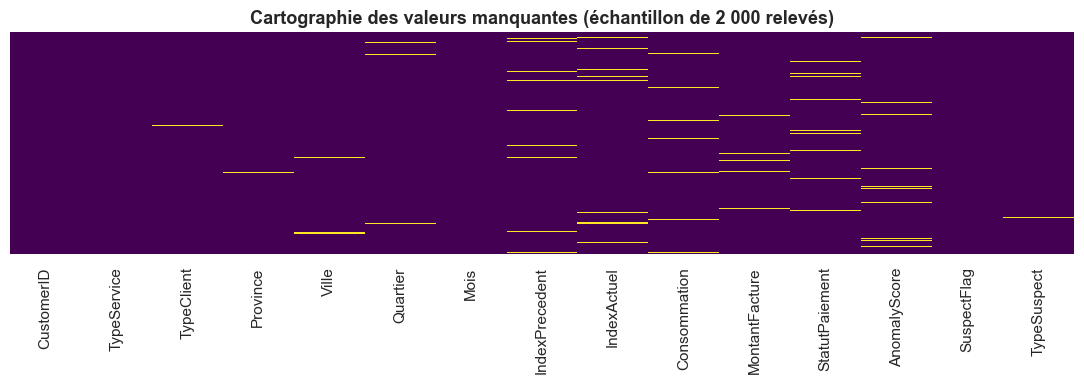

In [10]:
# Cartographie des valeurs manquantes (échantillon de 2000 lignes pour la lisibilité)
plt.figure(figsize=(11, 4))
sns.heatmap(df.sample(2000, random_state=RANDOM_STATE).isnull(),
            cbar=False, yticklabels=False, cmap='viridis')
plt.title("Cartographie des valeurs manquantes (échantillon de 2 000 relevés)")
plt.tight_layout()
plt.show()


#### c) Valeurs dupliquées

In [11]:
# Doublons stricts (lignes entièrement identiques)
nb_doublons = df.duplicated().sum()
print(f"Nombre de lignes strictement dupliquées : {nb_doublons:,} "
      f"({nb_doublons / len(df) * 100:.2f} % du dataset)")

# Doublons « métier » : même client, même mois, même service (relevé saisi deux fois)
cle_metier = ['CustomerID', 'Mois', 'TypeService']
nb_doublons_metier = df.duplicated(subset=cle_metier).sum()
print(f"Doublons sur la clé métier {cle_metier} : {nb_doublons_metier:,}")

Nombre de lignes strictement dupliquées : 211 (0.42 % du dataset)
Doublons sur la clé métier ['CustomerID', 'Mois', 'TypeService'] : 300


**Interprétation.** La présence de doublons stricts correspond le plus souvent à une double saisie d'un même relevé. Ces lignes n'apportent aucune information nouvelle et biaisent les statistiques (sur-représentation de certains profils) : elles seront supprimées lors du nettoyage.

#### d) Incohérences métier

In [12]:
# Règle métier 1 : Consommation = IndexActuel - IndexPrecedent (doit être >= 0)
masque_idx = df['IndexActuel'].notna() & df['IndexPrecedent'].notna()
ecart_index = df.loc[masque_idx, 'IndexActuel'] - df.loc[masque_idx, 'IndexPrecedent']
incoherence_index = (ecart_index < 0).sum()

# Règle métier 2 : une consommation physique ne peut être négative
conso_negative = (df['Consommation'] < 0).sum()

# Règle métier 3 : le score d'anomalie doit appartenir à l'intervalle [0, 1]
score_hors_borne = ((df['AnomalyScore'] < 0) | (df['AnomalyScore'] > 1)).sum()

# Règle métier 4 : cohérence entre SuspectFlag et TypeSuspect
#   - un relevé non suspect (flag=0) ne devrait pas porter de type de fraude
#   - un relevé suspect (flag=1) devrait avoir un type renseigné
flag0_avec_type = ((df['SuspectFlag'] == 0) & (df['TypeSuspect'].notna())
                   & (df['TypeSuspect'] != 'Aucune')).sum()
flag1_sans_type = ((df['SuspectFlag'] == 1)
                   & ((df['TypeSuspect'].isna()) | (df['TypeSuspect'] == 'Aucune'))).sum()

print("Synthèse des incohérences métier détectées")
print("-" * 55)
print(f"Index actuel < index précédent          : {incoherence_index:,}")
print(f"Consommation strictement négative        : {conso_negative:,}")
print(f"Score d'anomalie hors [0, 1]             : {score_hors_borne:,}")
print(f"Flag=0 mais type de fraude renseigné     : {flag0_avec_type:,}")
print(f"Flag=1 mais type de fraude manquant       : {flag1_sans_type:,}")

Synthèse des incohérences métier détectées
-------------------------------------------------------
Index actuel < index précédent          : 0
Consommation strictement négative        : 150
Score d'anomalie hors [0, 1]             : 100
Flag=0 mais type de fraude renseigné     : 100
Flag=1 mais type de fraude manquant       : 300


**Interprétation.** L'audit met en évidence des incohérences physiques et logiques :

- des relevés où l'**index courant est inférieur à l'index précédent**, ce qui est impossible pour un compteur classique (sauf remplacement de compteur ou erreur de saisie) ;
- des **consommations négatives**, aberrantes par nature ;
- des **incohérences entre `SuspectFlag` et `TypeSuspect`**, signe d'une saisie partielle des libellés de fraude.

Ces anomalies guideront les corrections de l'étape de nettoyage.

#### e) Valeurs aberrantes (*outliers*)

In [13]:
# Détection des outliers par la méthode de l'écart interquartile (IQR)
def compter_outliers_iqr(serie):
    s = serie.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    borne_basse, borne_haute = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    nb = ((s < borne_basse) | (s > borne_haute)).sum()
    return nb, borne_basse, borne_haute

cols_num = ['IndexPrecedent', 'IndexActuel', 'Consommation', 'MontantFacture', 'AnomalyScore']
resume_outliers = []
for c in cols_num:
    nb, bb, bh = compter_outliers_iqr(df[c])
    resume_outliers.append((c, nb, round(nb / df[c].notna().sum() * 100, 2), round(bb, 2), round(bh, 2)))

pd.DataFrame(resume_outliers,
             columns=['Variable', 'Nb outliers', '% outliers', 'Borne basse', 'Borne haute'])

,Variable,Nb outliers,% outliers,Borne basse,Borne haute
0,IndexPrecedent,0,0.00,"-92,930.13","293,352.91"
1,IndexActuel,0,0.00,"-92,980.44","293,875.48"
2,Consommation,4414,8.95,-292.09,557.27
3,MontantFacture,6615,13.35,-141.90,705.62
4,AnomalyScore,1406,2.90,-0.17,0.53


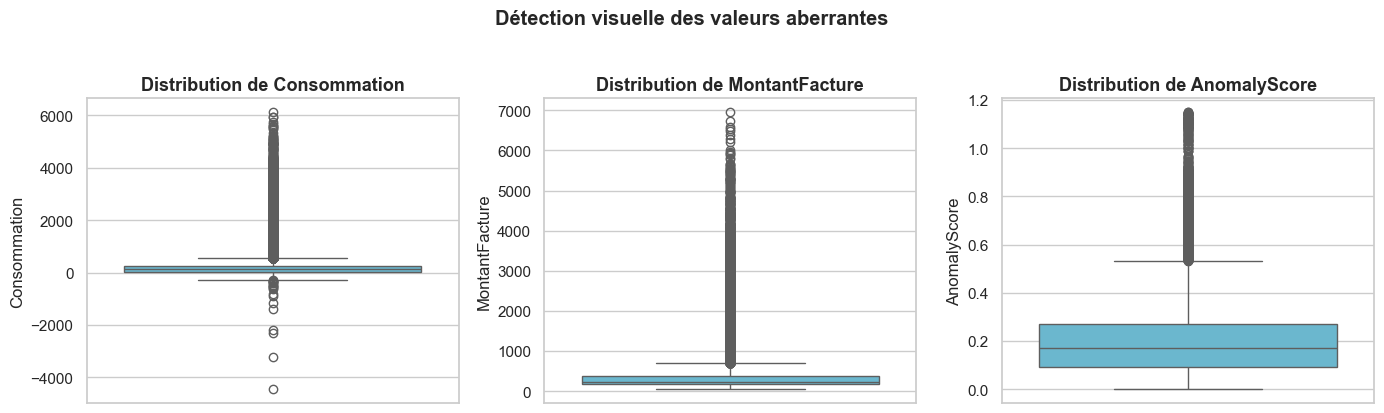

In [14]:
# Visualisation des outliers : boxplots des variables numériques clés
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['Consommation', 'MontantFacture', 'AnomalyScore']):
    sns.boxplot(y=df[col], ax=ax, color='#5bc0de')
    ax.set_title(f"Distribution de {col}")
plt.suptitle("Détection visuelle des valeurs aberrantes", y=1.03, fontweight='bold')
plt.tight_layout()
plt.show()

**Interprétation.** La consommation et le montant facturé présentent une **forte asymétrie à droite** : la majorité des relevés concernent des particuliers à faible consommation, tandis qu'une minorité de clients industriels génère des valeurs très élevées. Ces points extrêmes ne sont donc **pas tous des erreurs** : ils traduisent souvent une réalité métier légitime (gros consommateurs). La stratégie retenue ne sera pas une suppression aveugle mais un **plafonnement raisonné (*winsorisation*)** des valeurs physiquement impossibles ou extravagantes, afin de préserver l'information sans laisser les outliers fausser les statistiques et la mise à l'échelle.

#### f) Tableau de synthèse de l'audit

Le tableau ci-dessous consolide en une seule vue l'ensemble des défauts détectés lors de l'audit, avec leur ampleur et la décision de traitement retenue pour l'étape de nettoyage (§ 3.2.3). C'est ce tableau qui sera repris tel quel comme indicateur de qualité des données dans le tableau de bord Power BI du Chapitre 4.

In [15]:
# --- Tableau de synthèse unique de l'audit de qualité ---
n_total = len(df)

synthese_audit = pd.DataFrame([
    {
        'Défaut détecté': 'Valeurs manquantes (cumul, toutes colonnes)',
        'Nombre': int(manquantes['Nb manquants'].sum()),
        '% du dataset': round(manquantes['Nb manquants'].sum() / n_total * 100, 2),
        'Décision retenue': 'Imputation (médiane / mode)',
    },
    {
        'Défaut détecté': 'Doublons stricts',
        'Nombre': int(nb_doublons),
        '% du dataset': round(nb_doublons / n_total * 100, 2),
        'Décision retenue': 'Suppression',
    },
    {
        'Défaut détecté': 'Index actuel < index précédent',
        'Nombre': int(incoherence_index),
        '% du dataset': round(incoherence_index / n_total * 100, 2),
        'Décision retenue': 'Recalcul de la consommation à partir des index',
    },
    {
        'Défaut détecté': 'Consommations négatives',
        'Nombre': int(conso_negative),
        '% du dataset': round(conso_negative / n_total * 100, 2),
        'Décision retenue': 'Mise à NaN puis imputation',
    },
    {
        'Défaut détecté': 'AnomalyScore hors [0, 1]',
        'Nombre': int(score_hors_borne),
        '% du dataset': round(score_hors_borne / n_total * 100, 2),
        'Décision retenue': 'Signalé (variable exclue de la modélisation, § 3.3.3)',
    },
    {
        'Défaut détecté': 'Incohérence SuspectFlag / TypeSuspect',
        'Nombre': int(flag0_avec_type + flag1_sans_type),
        '% du dataset': round((flag0_avec_type + flag1_sans_type) / n_total * 100, 2),
        'Décision retenue': "Réalignement (TypeSuspect = 'Aucune' / 'Non précisé')",
    },
    {
        'Défaut détecté': 'Outliers (Consommation, IQR)',
        'Nombre': int(resume_outliers[2][1]),
        '% du dataset': resume_outliers[2][2],
        'Décision retenue': 'Winsorisation (plafonnement aux bornes IQR)',
    },
    {
        'Défaut détecté': 'Outliers (MontantFacture, IQR)',
        'Nombre': int(resume_outliers[3][1]),
        '% du dataset': resume_outliers[3][2],
        'Décision retenue': 'Winsorisation (plafonnement aux bornes IQR)',
    },
])
synthese_audit


,Défaut détecté,Nombre,% du dataset,Décision retenue
0,"Valeurs manquantes (cumul, toutes colonnes)",9947,19.77,Imputation (médiane / mode)
1,Doublons stricts,211,0.42,Suppression
2,Index actuel < index précédent,0,0.00,Recalcul de la consommation à partir des index
3,Consommations négatives,150,0.30,Mise à NaN puis imputation
4,"AnomalyScore hors [0, 1]",100,0.20,"Signalé (variable exclue de la modélisation, §..."
5,Incohérence SuspectFlag / TypeSuspect,400,0.80,Réalignement (TypeSuspect = 'Aucune' / 'Non pr...
6,"Outliers (Consommation, IQR)",4414,8.95,Winsorisation (plafonnement aux bornes IQR)
7,"Outliers (MontantFacture, IQR)",6615,13.35,Winsorisation (plafonnement aux bornes IQR)


### 3.2.3 Nettoyage des données

Sur la base de l'audit, nous appliquons les corrections dans un ordre logique : suppression des doublons, correction des incohérences métier, traitement des outliers, puis imputation des valeurs manquantes. Toutes les opérations sont effectuées sur une **copie** (`df_clean`) afin de préserver le jeu brut.

In [16]:
# On travaille sur une copie pour conserver l'original intact
df_clean = df.copy()
taille_initiale = len(df_clean)

# --- 1. Suppression des doublons stricts ---
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Doublons supprimés : {taille_initiale - len(df_clean):,}")
print(f"Lignes restantes   : {len(df_clean):,}")

Doublons supprimés : 211
Lignes restantes   : 50,100


In [17]:
# --- 2. Correction des incohérences métier ---
# 2a. Recalcul de la consommation à partir des index lorsque les deux sont présents :
#     c'est la source la plus fiable de la consommation réelle.
masque_idx = df_clean['IndexActuel'].notna() & df_clean['IndexPrecedent'].notna()
df_clean.loc[masque_idx, 'Consommation'] = (
    df_clean.loc[masque_idx, 'IndexActuel'] - df_clean.loc[masque_idx, 'IndexPrecedent']
)

# 2b. Les consommations négatives (index décroissant : remplacement de compteur,
#     erreur de saisie) sont physiquement impossibles -> on les marque comme manquantes
#     pour les imputer proprement par la suite.
nb_neg = (df_clean['Consommation'] < 0).sum()
df_clean.loc[df_clean['Consommation'] < 0, 'Consommation'] = np.nan
print(f"Consommations négatives neutralisées (mises à NaN puis imputées) : {nb_neg:,}")

# 2c. Cohérence SuspectFlag / TypeSuspect :
#     - si le relevé n'est pas suspect, le type de fraude doit être 'Aucune'
#     - si le relevé est suspect mais sans type, on le qualifie de 'Non précisé'
df_clean.loc[df_clean['SuspectFlag'] == 0, 'TypeSuspect'] = 'Aucune'
df_clean.loc[(df_clean['SuspectFlag'] == 1) &
             ((df_clean['TypeSuspect'].isna()) | (df_clean['TypeSuspect'] == 'Aucune')),
             'TypeSuspect'] = 'Non précisé'
print("Cohérence SuspectFlag / TypeSuspect rétablie.")

Consommations négatives neutralisées (mises à NaN puis imputées) : 7
Cohérence SuspectFlag / TypeSuspect rétablie.


In [18]:
# --- 3. Gestion des outliers par winsorisation (plafonnement aux bornes IQR) ---
# On plafonne uniquement les variables physiques pour limiter l'effet des valeurs
# extravagantes sur la standardisation, sans supprimer de lignes.
def winsoriser(serie, k=1.5):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    bb, bh = q1 - k * iqr, q3 + k * iqr
    return serie.clip(lower=bb, upper=bh), bb, bh

for col in ['Consommation', 'MontantFacture']:
    avant = df_clean[col].max()
    df_clean[col], bb, bh = winsoriser(df_clean[col])
    print(f"{col:<15} plafonné à [{bb:,.1f} ; {bh:,.1f}]  (max avant : {avant:,.1f})")

Consommation    plafonné à [-292.6 ; 558.5]  (max avant : 6,126.5)
MontantFacture  plafonné à [-141.8 ; 705.6]  (max avant : 6,952.8)


In [19]:
# --- 4. Imputation des valeurs manquantes ---
# Variables numériques -> médiane (robuste aux valeurs extrêmes restantes)
cols_num_impute = ['IndexPrecedent', 'IndexActuel', 'Consommation', 'MontantFacture', 'AnomalyScore']
for col in cols_num_impute:
    mediane = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(mediane)

# Variables catégorielles -> modalité la plus fréquente (mode)
cols_cat_impute = ['TypeClient', 'Province', 'Ville', 'Quartier', 'StatutPaiement']
for col in cols_cat_impute:
    mode = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode)

# Vérification : plus aucune valeur manquante
total_restant = df_clean.isnull().sum().sum()
print(f"Valeurs manquantes restantes après imputation : {total_restant}")
assert total_restant == 0, "Des valeurs manquantes subsistent !"
print("Nettoyage terminé : jeu de données complet et cohérent.")

Valeurs manquantes restantes après imputation : 0
Nettoyage terminé : jeu de données complet et cohérent.


**Interprétation.** Le nettoyage a permis de : (i) éliminer les redondances, (ii) rétablir la cohérence physique de la consommation à partir des index, (iii) contenir l'effet des valeurs extrêmes par winsorisation et (iv) compléter les trous par une imputation robuste (médiane pour le numérique, mode pour le catégoriel). Le choix de la **médiane** plutôt que de la moyenne se justifie par l'asymétrie des distributions observée à l'audit. Aucune ligne utile n'a été sacrifiée, ce qui préserve le volume nécessaire à l'apprentissage.

### 3.2.4 Transformation des données

La transformation rend les données exploitables par les algorithmes : conversion des dates, encodage des variables catégorielles et mise à l'échelle des variables numériques.

#### a) Conversion des dates

In [20]:
# Conversion de la colonne texte 'Mois' (AAAA-MM) en type datetime
df_clean['Date'] = pd.to_datetime(df_clean['Mois'], format='%Y-%m')
print("Type de la colonne 'Date' :", df_clean['Date'].dtype)
print(f"Période couverte : du {df_clean['Date'].min():%Y-%m} au {df_clean['Date'].max():%Y-%m}")

Type de la colonne 'Date' : datetime64[ns]
Période couverte : du 2010-01 au 2025-11


#### b) Encodage des variables catégorielles

Les algorithmes de *machine learning* ne traitent que des valeurs numériques. Nous encodons les variables catégorielles par **Label Encoding**, en conservant systématiquement la version textuelle originale (`*_label`) pour les besoins de l'analyse exploratoire et de la restitution. Le *one-hot encoding* est écarté ici pour les variables à forte cardinalité (`Ville` : 74 modalités) afin d'éviter une explosion dimensionnelle ; les modèles à base d'arbres (Random Forest, XGBoost) gèrent très bien le label encoding.

In [21]:
# Sauvegarde des libellés d'origine, puis encodage numérique
df_clean['TypeService_label']   = df_clean['TypeService']
df_clean['TypeClient_label']    = df_clean['TypeClient']
df_clean['Province_label']      = df_clean['Province']
df_clean['StatutPaiement_label']= df_clean['StatutPaiement']

encodeurs = {}
for col in ['TypeService', 'TypeClient', 'Province', 'Ville', 'Quartier', 'StatutPaiement']:
    le = LabelEncoder()
    df_clean[col + '_enc'] = le.fit_transform(df_clean[col].astype(str))
    encodeurs[col] = le

# Exemple de correspondance pour TypeClient
correspondance = dict(zip(encodeurs['TypeClient'].classes_,
                          encodeurs['TypeClient'].transform(encodeurs['TypeClient'].classes_)))
print("Exemple d'encodage — TypeClient :")
for k, v in correspondance.items():
    print(f"   {k:<15} -> {v}")

Exemple d'encodage — TypeClient :
   Administration  -> 0
   Commerce        -> 1
   Industrie       -> 2
   Particulier     -> 3


#### c) Normalisation / Standardisation

La **standardisation** (*z-score* : moyenne 0, écart-type 1) est appliquée aux variables numériques continues. Elle est indispensable pour les algorithmes sensibles à l'échelle (régression logistique, SVM, k-NN, k-means) et pour la convergence de SMOTE, qui repose sur des distances. On conserve les colonnes brutes et on ajoute des colonnes standardisées suffixées `_std`.

In [22]:
# Standardisation (z-score) des variables numériques continues
cols_a_standardiser = ['IndexPrecedent', 'IndexActuel', 'Consommation', 'MontantFacture', 'AnomalyScore']
scaler = StandardScaler()
df_clean[[c + '_std' for c in cols_a_standardiser]] = scaler.fit_transform(df_clean[cols_a_standardiser])

# Contrôle : moyenne ~ 0 et écart-type ~ 1 après standardisation
controle = df_clean[[c + '_std' for c in cols_a_standardiser]].agg(['mean', 'std']).T
controle.columns = ['Moyenne (~0)', 'Écart-type (~1)']
controle.round(4)

,Moyenne (~0),Écart-type (~1)
IndexPrecedent_std,-0.00,1.00
IndexActuel_std,-0.00,1.00
Consommation_std,0.00,1.00
MontantFacture_std,0.00,1.00
AnomalyScore_std,-0.00,1.00


**Interprétation.** Après standardisation, chaque variable est ramenée à une échelle comparable (moyenne nulle, dispersion unitaire). Aucune variable ne domine plus artificiellement les autres du fait de son unité de mesure (kWh, m³, MAD), ce qui est une condition nécessaire pour les algorithmes basés sur la distance et pour un rééchantillonnage SMOTE pertinent.

### 3.2.5 Feature Engineering

Le *feature engineering* consiste à créer de nouvelles variables porteuses de sens métier, susceptibles d'améliorer le pouvoir prédictif des modèles. C'est souvent ici que se gagne la performance. Nous construisons trois familles de variables : **calendaires**, **comportementales (historique du client)** et **contextuelles marocaines** (Ramadan, Aïd, saisons).

In [23]:
# Tri chronologique par client : indispensable pour calculer les variables d'historique
df_feat = df_clean.sort_values(['CustomerID', 'Date']).reset_index(drop=True)

# --- 1. Variables calendaires ---
df_feat['Annee']     = df_feat['Date'].dt.year      # Année du relevé
df_feat['Mois_num']  = df_feat['Date'].dt.month     # Mois (1-12)
df_feat['Trimestre'] = df_feat['Date'].dt.quarter   # Trimestre (1-4)

# --- 2. Saison (hémisphère nord) ---
def determiner_saison(mois):
    if mois in (12, 1, 2):   return 'Hiver'
    if mois in (3, 4, 5):    return 'Printemps'
    if mois in (6, 7, 8):    return 'Été'
    return 'Automne'
df_feat['Saison'] = df_feat['Mois_num'].apply(determiner_saison)

# Indicateurs binaires Été / Hiver (pics de demande clim. / chauffage)
df_feat['Is_Ete']   = df_feat['Mois_num'].isin([6, 7, 8]).astype(int)
df_feat['Is_Hiver'] = df_feat['Mois_num'].isin([12, 1, 2]).astype(int)
print("Variables calendaires créées : Annee, Mois_num, Trimestre, Saison, Is_Ete, Is_Hiver")

Variables calendaires créées : Annee, Mois_num, Trimestre, Saison, Is_Ete, Is_Hiver


In [24]:
# --- 3. Variables contextuelles marocaines : Ramadan et Aïd ---
# Le mois du Ramadan se décale d'environ 11 jours chaque année (calendrier lunaire).
# On associe à chaque année le mois grégorien dominant du Ramadan (approximation métier).
mois_ramadan = {2010: 8, 2011: 8, 2012: 7, 2013: 7, 2014: 6, 2015: 6, 2016: 6,
                2017: 5, 2018: 5, 2019: 5, 2020: 4, 2021: 4, 2022: 4, 2023: 3,
                2024: 3, 2025: 2}

# Is_Ramadan : 1 si le mois du relevé correspond au mois dominant du Ramadan de l'année
df_feat['Is_Ramadan'] = df_feat.apply(
    lambda r: int(mois_ramadan.get(r['Annee'], -1) == r['Mois_num']), axis=1)

# Is_Aid : Aïd al-Fitr survient le mois suivant la fin du Ramadan (pic de consommation)
df_feat['Is_Aid'] = df_feat.apply(
    lambda r: int(mois_ramadan.get(r['Annee'], -99) + 1 == r['Mois_num']), axis=1)

print(f"Relevés en période de Ramadan : {df_feat['Is_Ramadan'].sum():,}")
print(f"Relevés en période d'Aïd      : {df_feat['Is_Aid'].sum():,}")

Relevés en période de Ramadan : 4,293
Relevés en période d'Aïd      : 4,308


In [25]:
# --- 4. Variables comportementales (historique propre à chaque client) ---
# 4a. Consommation du relevé précédent (décalage temporel par client)
df_feat['Conso_Precedente'] = df_feat.groupby('CustomerID')['Consommation'].shift(1)

# 4b. Consommation moyenne historique du client (profil de référence)
df_feat['Conso_Moyenne_Client'] = df_feat.groupby('CustomerID')['Consommation'].transform('mean')

# 4c. Taux d'évolution (%) par rapport au relevé précédent :
#     un effondrement soudain est un signal de fraude bien plus parlant
#     qu'une valeur basse dans l'absolu (cf. état de l'art, Ch. 2).
df_feat['Taux_Evolution'] = (
    (df_feat['Consommation'] - df_feat['Conso_Precedente'])
    / df_feat['Conso_Precedente'].replace(0, np.nan) * 100
)

# 4d. Écart relatif à la moyenne du client (anomalie comportementale)
df_feat['Ecart_Moyenne_Client'] = (
    (df_feat['Consommation'] - df_feat['Conso_Moyenne_Client'])
    / df_feat['Conso_Moyenne_Client'].replace(0, np.nan)
)
print("Variables comportementales créées : Conso_Precedente, Conso_Moyenne_Client, "
      "Taux_Evolution, Ecart_Moyenne_Client")

Variables comportementales créées : Conso_Precedente, Conso_Moyenne_Client, Taux_Evolution, Ecart_Moyenne_Client


In [26]:
# --- 5. Nettoyage des variables dérivées ---
# Le taux d'évolution peut produire des infinis (division par ~0) ou des valeurs
# extravagantes : on neutralise les infinis puis on plafonne aux 1er/99e percentiles.
for col in ['Taux_Evolution', 'Ecart_Moyenne_Client']:
    df_feat[col] = df_feat[col].replace([np.inf, -np.inf], np.nan)
    p1, p99 = df_feat[col].quantile([0.01, 0.99])
    df_feat[col] = df_feat[col].clip(p1, p99)

# Imputation des variables d'historique manquantes (1er relevé de chaque client) :
# - Conso_Precedente : valeur courante (hypothèse de stabilité)
# - Taux_Evolution / Ecart : 0 (pas d'évolution observable au premier relevé)
df_feat['Conso_Precedente']     = df_feat['Conso_Precedente'].fillna(df_feat['Consommation'])
df_feat['Taux_Evolution']       = df_feat['Taux_Evolution'].fillna(0)
df_feat['Ecart_Moyenne_Client'] = df_feat['Ecart_Moyenne_Client'].fillna(0)

print("Valeurs manquantes restantes :", int(df_feat.isnull().sum().sum()))
print(f"Dataset enrichi : {df_feat.shape[0]:,} lignes x {df_feat.shape[1]} colonnes")

Valeurs manquantes restantes : 0
Dataset enrichi : 50,100 lignes x 43 colonnes


In [27]:
# Aperçu des nouvelles variables créées
nouvelles_vars = ['CustomerID', 'Date', 'Consommation', 'Conso_Precedente',
                  'Conso_Moyenne_Client', 'Taux_Evolution', 'Saison',
                  'Is_Ramadan', 'Is_Aid', 'Is_Ete']
df_feat[nouvelles_vars].head(8)

,CustomerID,Date,Consommation,Conso_Precedente,Conso_Moyenne_Client,Taux_Evolution,Saison,Is_Ramadan,Is_Aid,Is_Ete
0,C000000,2017-02-01,79.42,79.42,127.13,0.00,Hiver,0,0,0
1,C000000,2017-03-01,95.58,79.42,127.13,20.35,Printemps,0,0,0
2,C000000,2017-04-01,117.74,95.58,127.13,23.18,Printemps,0,0,0
3,C000000,2017-05-01,142.80,117.74,127.13,21.28,Printemps,1,0,0
4,C000000,2017-06-01,154.63,142.80,127.13,8.28,Été,0,1,1
5,C000000,2017-07-01,200.66,154.63,127.13,29.77,Été,0,0,1
6,C000000,2017-08-01,157.40,200.66,127.13,-21.56,Été,0,0,1
7,C000000,2017-09-01,167.81,157.40,127.13,6.61,Automne,0,0,0


**Interprétation.** Les variables d'ingénierie traduisent des hypothèses métier fortes :

- **`Taux_Evolution` et `Ecart_Moyenne_Client`** capturent l'écart d'un relevé par rapport à l'historique propre du client. Une chute brutale de consommation, même vers une valeur « normale » dans l'absolu, est un marqueur classique de fraude (compteur trafiqué, dérivation).
- **`Conso_Moyenne_Client`** établit un profil de référence individuel, permettant de raisonner *relativement* et non *absolument*.
- **Les variables calendaires et contextuelles** (Saison, Ramadan, Aïd, Été/Hiver) modélisent la saisonnalité de la demande, spécifique au contexte marocain — un levier important tant pour la prévision que pour distinguer une variation saisonnière légitime d'une anomalie.

**Valorisation métier des variables créées.** Le tableau suivant explicite, pour chaque variable issue du *feature engineering*, l'hypothèse métier qui la motive et le type de comportement frauduleux qu'elle est censée révéler. C'est cette table de lecture qui constitue la contribution la plus spécifique de ce chapitre : elle transforme des calculs statistiques en signaux interprétables pour un gestionnaire SRM.

| Variable créée | Hypothèse métier | Ce qu'elle détecte |
|---|---|---|
| `Taux_Evolution` | Une fraude s'accompagne souvent d'une **rupture brutale** de consommation par rapport au relevé précédent | Chute soudaine de consommation → compteur trafiqué ou dérivation |
| `Ecart_Moyenne_Client` | Le comportement de référence d'un client est individuel : une valeur « normale » dans l'absolu peut être anormale pour *ce* client | Écart durable au profil habituel → fraude installée dans la durée |
| `Conso_Moyenne_Client` | Sert de ligne de base personnalisée aux deux variables précédentes | Permet de raisonner en relatif plutôt qu'en absolu |
| `Is_Ramadan`, `Is_Aid` | La consommation marocaine varie fortement lors des périodes religieuses (horaires, réceptions) | Évite de confondre une variation saisonnière légitime avec une anomalie |
| `Is_Ete`, `Is_Hiver`, `Saison` | La climatisation (été) et le chauffage (hiver) créent des pics de demande prévisibles | Contextualise les pics de consommation avant de les qualifier de suspects |
| `Trimestre`, `Mois_num`, `Annee` | Capture les tendances de long terme et les effets calendaires structurels | Permet au modèle de distinguer tendance, saisonnalité et anomalie ponctuelle |


## 3.3 Gestion du Déséquilibre des Classes

La détection de fraude est par nature un problème **fortement déséquilibré** : les comportements suspects sont rares face à la masse des relevés normaux. Cette section quantifie le déséquilibre, explique pourquoi l'*accuracy* (exactitude) est trompeuse, puis compare trois stratégies de rééchantillonnage.

### 3.3.1 Distribution des classes

In [28]:
# Distribution de la variable cible SuspectFlag
distribution = df_feat['SuspectFlag'].value_counts().sort_index()
proportions  = df_feat['SuspectFlag'].value_counts(normalize=True).sort_index() * 100

print("Distribution de la variable cible 'SuspectFlag'")
print("-" * 50)
print(f"Classe 0 (Normal)  : {distribution[0]:>8,}  ({proportions[0]:.2f} %)")
print(f"Classe 1 (Suspect) : {distribution[1]:>8,}  ({proportions[1]:.2f} %)")

ratio = distribution[0] / distribution[1]
print(f"\nRatio de déséquilibre (Normal : Suspect) = {ratio:.1f} : 1")

Distribution de la variable cible 'SuspectFlag'
--------------------------------------------------
Classe 0 (Normal)  :   48,906  (97.62 %)
Classe 1 (Suspect) :    1,194  (2.38 %)

Ratio de déséquilibre (Normal : Suspect) = 41.0 : 1


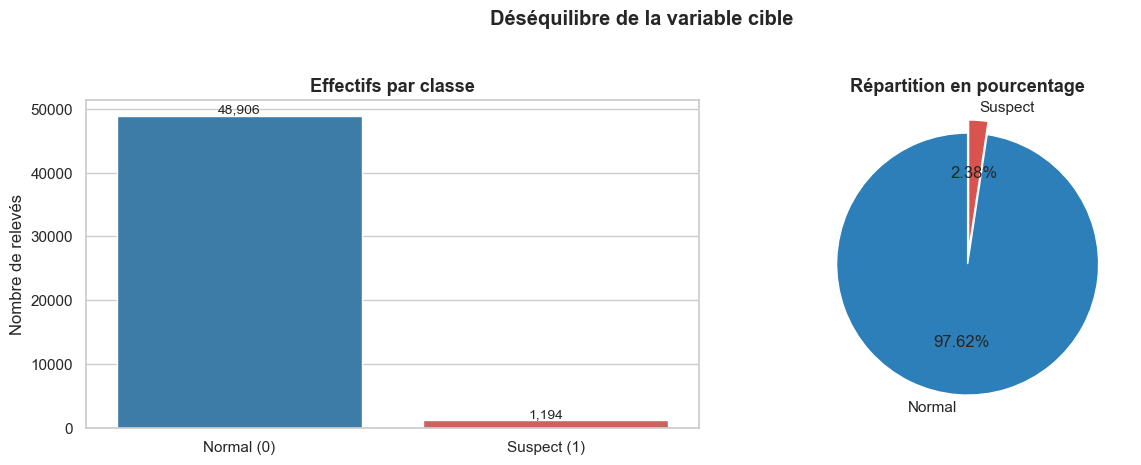

In [29]:
# Visualisation du déséquilibre
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Diagramme en barres
sns.countplot(x='SuspectFlag', data=df_feat, ax=axes[0],
              palette=['#2c7fb8', '#d9534f'])
axes[0].set_title("Effectifs par classe")
axes[0].set_xticklabels(['Normal (0)', 'Suspect (1)'])
axes[0].set_xlabel(''); axes[0].set_ylabel('Nombre de relevés')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Diagramme circulaire
axes[1].pie(distribution, labels=['Normal', 'Suspect'], autopct='%1.2f%%',
            colors=['#2c7fb8', '#d9534f'], startangle=90, explode=(0, 0.1))
axes[1].set_title("Répartition en pourcentage")

plt.suptitle("Déséquilibre de la variable cible", y=1.03, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3.2 Pourquoi l'*accuracy* ne suffit pas

Avec un ratio de l'ordre de **41 relevés normaux pour 1 relevé suspect**, un classifieur naïf qui prédirait *systématiquement « normal »* atteindrait une **exactitude (*accuracy*) supérieure à 97 %**… tout en étant **totalement inutile** : il ne détecterait **aucune fraude**. L'exactitude est dominée par la classe majoritaire et masque l'échec sur la classe d'intérêt.

On évalue donc les modèles sur des métriques centrées sur la classe positive (fraude) :

| Métrique | Définition | Ce qu'elle mesure |
|---|---|---|
| **Précision** | VP / (VP + FP) | Parmi les relevés signalés suspects, la part réellement frauduleuse (coût des fausses alertes) |
| **Rappel (*Recall*)** | VP / (VP + FN) | Parmi les fraudes réelles, la part effectivement détectée (coût des fraudes manquées) |
| **F1-score** | Moyenne harmonique Précision/Rappel | Équilibre entre les deux |
| **PR-AUC** | Aire sous la courbe Précision-Rappel | Performance globale, **adaptée aux classes déséquilibrées** (préférée à la ROC-AUC) |

VP : vrais positifs · FP : faux positifs · FN : faux négatifs.

**Lecture coût/bénéfice pour la SRM.** Au-delà des définitions statistiques, ces métriques se traduisent directement en décisions de gestion : un **faux positif** (relevé signalé à tort) coûte le déplacement d'un agent de contrôle pour un résultat négatif — un coût **faible et ponctuel**. Un **faux négatif** (fraude non détectée) prolonge une perte financière chaque mois jusqu'à la détection — un coût **élevé et cumulatif**. Cette asymétrie de coûts justifie, en langage de gestionnaire et non de seul *data scientist*, de **privilégier le rappel** au niveau de précision fixé par la capacité de contrôle terrain de la SRM (§ 3.3.7).

In [30]:
# Démonstration chiffrée : le classifieur « toujours normal »
y_demo = df_feat['SuspectFlag']
y_pred_naif = np.zeros(len(y_demo))  # prédit toujours 0 (normal)

from sklearn.metrics import accuracy_score
print("Classifieur naïf « toujours Normal » :")
print(f"   Accuracy : {accuracy_score(y_demo, y_pred_naif):.4f}  <-- trompeusement élevée")
print(f"   Rappel   : {recall_score(y_demo, y_pred_naif, zero_division=0):.4f}  <-- aucune fraude détectée !")
print(f"   F1-score : {f1_score(y_demo, y_pred_naif, zero_division=0):.4f}")
print("\nConclusion : l'accuracy seule donne une illusion de performance.")

Classifieur naïf « toujours Normal » :
   Accuracy : 0.9762  <-- trompeusement élevée
   Rappel   : 0.0000  <-- aucune fraude détectée !
   F1-score : 0.0000

Conclusion : l'accuracy seule donne une illusion de performance.


### 3.3.3 Préparation de la matrice de modélisation et découpage train/test

Le rééchantillonnage ne doit **jamais** être appliqué à l'ensemble des données : il ne concerne que **l'échantillon d'apprentissage**. Rééchantillonner avant le découpage entraînerait une fuite d'information (*data leakage*) et une évaluation biaisée. On découpe donc d'abord en train/test (stratifié), puis on rééchantillonne **uniquement le train**.

In [31]:
# Sélection des variables explicatives pour la modélisation de la fraude
features_modele = [
    'Consommation', 'MontantFacture', 'IndexActuel', 'IndexPrecedent',
    'Conso_Precedente', 'Conso_Moyenne_Client', 'Taux_Evolution', 'Ecart_Moyenne_Client',
    'Annee', 'Mois_num', 'Trimestre', 'Is_Ete', 'Is_Hiver', 'Is_Ramadan', 'Is_Aid',
    'TypeService_enc', 'TypeClient_enc', 'Province_enc', 'StatutPaiement_enc'
]
X = df_feat[features_modele].copy()
y = df_feat['SuspectFlag'].copy()

# Découpage stratifié : on conserve la même proportion de fraude dans train et test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

print(f"Train : {X_train.shape[0]:,} relevés  ({y_train.mean()*100:.2f} % de fraude)")
print(f"Test  : {X_test.shape[0]:,} relevés  ({y_test.mean()*100:.2f} % de fraude)")

Train : 37,575 relevés  (2.38 % de fraude)
Test  : 12,525 relevés  (2.38 % de fraude)


**Choix des variables et prévention de la fuite de la cible (*data leakage*).** Deux colonnes du jeu de données sont **volontairement exclues** de `features_modele` :

- **`TypeSuspect`** est directement dérivée du label (`Aucune` dès que `SuspectFlag = 0`) : l'inclure reviendrait à donner la réponse au modèle.
- **`AnomalyScore`** est un indicateur de suspicion **déjà produit par le système d'information**. Si l'étiquette `SuspectFlag` a été construite (même partiellement) à partir de ce score, alors `AnomalyScore` constitue une **fuite de la cible** et doit rester exclu, sous peine de performances artificiellement gonflées et non reproductibles en production. Nous l'écartons donc par prudence ; l'objectif est précisément de bâtir un modèle capable de détecter la fraude **à partir des données métier brutes**, indépendamment du score existant.

Ce choix garantit que les performances mesurées reflètent un réel pouvoir prédictif, et non une simple recopie d'un signal déjà calculé en amont.

### 3.3.4 Application des stratégies de rééchantillonnage

Nous comparons plusieurs approches, appliquées **au seul jeu d'apprentissage** :

- **Random Oversampling** — duplique aléatoirement des relevés de la classe minoritaire.
- **Random Undersampling** — supprime aléatoirement des relevés de la classe majoritaire.
- **SMOTE-NC** (*Synthetic Minority Over-sampling for Nominal and Continuous*) — variante de SMOTE **adaptée aux jeux mixtes** : elle génère des exemples synthétiques par interpolation pour les variables continues, mais choisit la modalité majoritaire des voisins pour les variables catégorielles. C'est essentiel ici, car nos variables encodées (`TypeService_enc`, `TypeClient_enc`, `Province_enc`, `StatutPaiement_enc`) sont *nominales* : un SMOTE classique produirait des valeurs interpolées absurdes (p. ex. une province « 2,7 »).
- **Pondération des classes** (`class_weight='balanced'`, § 3.3.5) — approche *cost-sensitive* qui ne modifie pas les données mais pénalise davantage les erreurs sur la classe minoritaire. Testée en complément pour comparer rééchantillonnage et repondération.

In [32]:
# Application des techniques de rééchantillonnage sur le TRAIN uniquement
# Repérage des colonnes catégorielles encodées : SMOTE-NC doit les traiter
# comme nominales (et non interpoler entre leurs codes numériques).
# On déclare comme catégorielles : les variables encodées (nominales) ET les
# indicateurs binaires / calendaires discrets. Sans cela, SMOTE-NC les
# interpolerait comme des continues et produirait des valeurs absurdes
# (p. ex. Is_Ete = 0,37 pour un drapeau qui ne peut valoir que 0 ou 1).
cols_categorielles = ['TypeService_enc', 'TypeClient_enc', 'Province_enc', 'StatutPaiement_enc',
                      'Is_Ete', 'Is_Hiver', 'Is_Ramadan', 'Is_Aid', 'Trimestre', 'Mois_num']
idx_categorielles = [X_train.columns.get_loc(c) for c in cols_categorielles]

ros     = RandomOverSampler(random_state=RANDOM_STATE)
rus     = RandomUnderSampler(random_state=RANDOM_STATE)
smotenc = SMOTENC(categorical_features=idx_categorielles,
                  random_state=RANDOM_STATE, k_neighbors=5)

X_ros, y_ros     = ros.fit_resample(X_train, y_train)
X_rus, y_rus     = rus.fit_resample(X_train, y_train)
# On conserve les noms X_smote / y_smote pour la suite (SMOTE-NC remplace SMOTE)
X_smote, y_smote = smotenc.fit_resample(X_train, y_train)

resume_resampling = pd.DataFrame({
    'Stratégie': ['Original (train)', 'Random Oversampling', 'Random Undersampling', 'SMOTE-NC'],
    'Total': [len(y_train), len(y_ros), len(y_rus), len(y_smote)],
    'Classe 0 (Normal)': [(y_train==0).sum(), (y_ros==0).sum(), (y_rus==0).sum(), (y_smote==0).sum()],
    'Classe 1 (Suspect)': [(y_train==1).sum(), (y_ros==1).sum(), (y_rus==1).sum(), (y_smote==1).sum()],
})
resume_resampling

,Stratégie,Total,Classe 0 (Normal),Classe 1 (Suspect)
0,Original (train),37575,36679,896
1,Random Oversampling,73358,36679,36679
2,Random Undersampling,1792,896,896
3,SMOTE-NC,73358,36679,36679


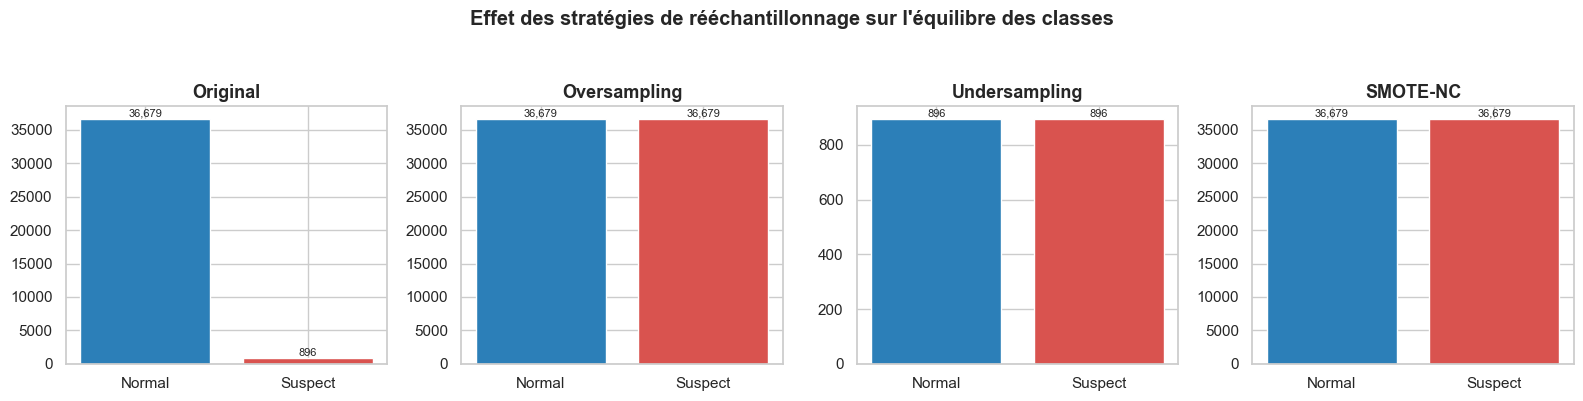

In [33]:
# Visualisation comparative de l'effet des trois stratégies
strategies = {'Original': y_train, 'Oversampling': y_ros,
              'Undersampling': y_rus, 'SMOTE-NC': y_smote}
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharey=False)
for ax, (nom, yy) in zip(axes, strategies.items()):
    vc = pd.Series(yy).value_counts().sort_index()
    ax.bar(['Normal', 'Suspect'], vc.values, color=['#2c7fb8', '#d9534f'])
    ax.set_title(nom)
    for i, v in enumerate(vc.values):
        ax.text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
plt.suptitle("Effet des stratégies de rééchantillonnage sur l'équilibre des classes",
             y=1.05, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3.5 Comparaison des stratégies et choix justifié

Pour départager les stratégies, nous entraînons un même classifieur (régression logistique, rapide et sensible au déséquilibre) sur chaque version du train, et nous l'évaluons sur le **même jeu de test intact**. Nous ajoutons à la comparaison une **stratégie sans rééchantillonnage mais avec pondération des classes** (`class_weight='balanced'`), afin de confronter l'approche *rééchantillonnage* à l'approche *cost-sensitive*. Les métriques retenues sont la Précision, le Rappel, le F1-score et le PR-AUC.

In [34]:
# Mise à l'échelle (la régression logistique y est sensible) — ajustée sur le train
scaler_eval = StandardScaler().fit(X_train)
X_test_s = scaler_eval.transform(X_test)

def evaluer_strategie(nom, X_res, y_res, class_weight=None):
    Xr = scaler_eval.transform(X_res)
    clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                             class_weight=class_weight)
    clf.fit(Xr, y_res)
    y_pred  = clf.predict(X_test_s)
    y_proba = clf.predict_proba(X_test_s)[:, 1]
    return {
        'Stratégie': nom,
        'Précision': precision_score(y_test, y_pred, zero_division=0),
        'Rappel': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
        'PR-AUC': average_precision_score(y_test, y_proba),
    }

resultats = pd.DataFrame([
    evaluer_strategie('Sans rééchantillonnage',      X_train, y_train),
    evaluer_strategie('Pondération (class_weight)',  X_train, y_train, class_weight='balanced'),
    evaluer_strategie('Random Oversampling',         X_ros,   y_ros),
    evaluer_strategie('Random Undersampling',        X_rus,   y_rus),
    evaluer_strategie('SMOTE-NC',                    X_smote, y_smote),
]).set_index('Stratégie').round(4)
resultats

,Précision,Rappel,F1-score,PR-AUC
Stratégie,,,,
Sans rééchantillonnage,0.85,0.33,0.48,0.55
Pondération (class_weight),0.11,0.81,0.19,0.49
Random Oversampling,0.11,0.81,0.19,0.49
Random Undersampling,0.10,0.81,0.18,0.49
SMOTE-NC,0.10,0.73,0.18,0.41


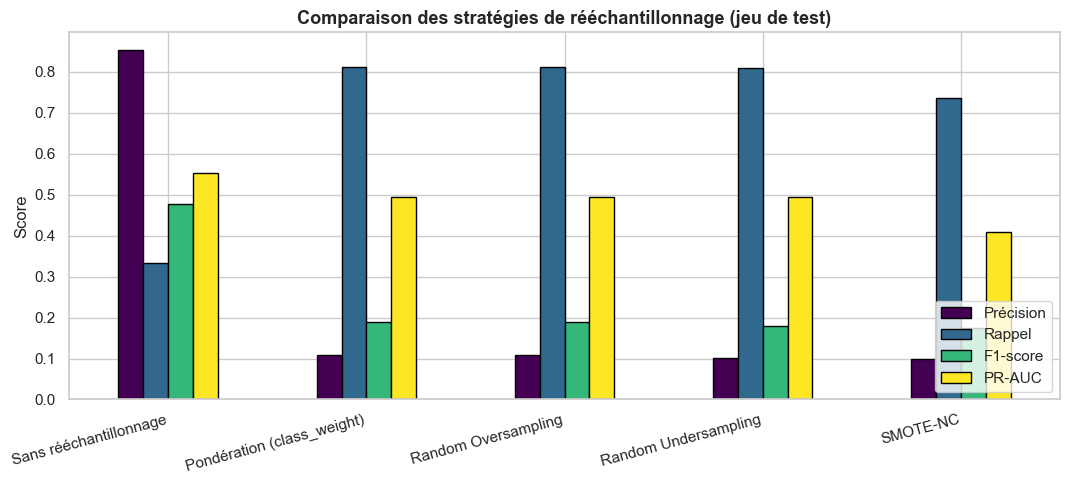

In [35]:
# Visualisation comparative des métriques
ax = resultats.plot(kind='bar', figsize=(11, 5), colormap='viridis', edgecolor='black')
ax.set_title("Comparaison des stratégies de rééchantillonnage (jeu de test)")
ax.set_ylabel("Score"); ax.set_xlabel("")
ax.legend(loc='lower right')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

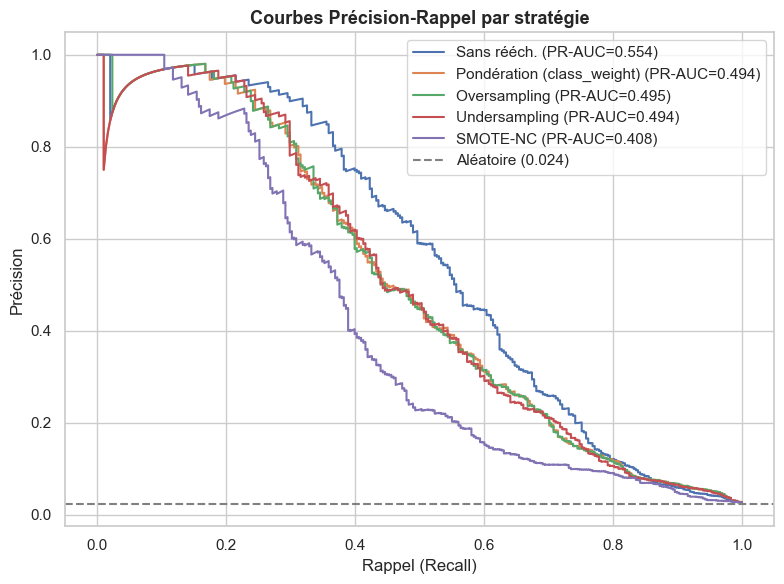

In [36]:
# Courbes Précision-Rappel pour chaque stratégie
# (nom, X_train_variant, y_train_variant, class_weight)
strategies_pr = [
    ('Sans rééch.',                (X_train, y_train, None)),
    ('Pondération (class_weight)', (X_train, y_train, 'balanced')),
    ('Oversampling',               (X_ros,   y_ros,   None)),
    ('Undersampling',              (X_rus,   y_rus,   None)),
    ('SMOTE-NC',                   (X_smote, y_smote, None)),
]

plt.figure(figsize=(8, 6))
for nom, (Xr, yr, cw) in strategies_pr:
    clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight=cw)
    clf.fit(scaler_eval.transform(Xr), yr)
    proba = clf.predict_proba(X_test_s)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(rec, prec, label=f'{nom} (PR-AUC={ap:.3f})')

plt.axhline(y_test.mean(), ls='--', color='grey',
            label=f'Aléatoire ({y_test.mean():.3f})')
plt.xlabel('Rappel (Recall)'); plt.ylabel('Précision')
plt.title('Courbes Précision-Rappel par stratégie')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

**Lecture des résultats et méthode retenue.** L'analyse se centre sur la *classe fraude*, et non sur des métriques globales dominées par la classe majoritaire. Les ordres de grandeur dépendent des données et de la graine ; c'est la **lecture qualitative** qui compte.

Sur la **régression logistique** — modèle linéaire, choisi comme criblage rapide — toutes les techniques de rééquilibrage (pondération, oversampling, undersampling, SMOTE-NC) produisent le même effet : elles **font bondir le rappel mais effondrent la précision** (multiplication des fausses alertes), au point que le F1 et le PR-AUC ne s'améliorent pas — voire régressent — par rapport au modèle sans rééchantillonnage. Ce n'est pas un échec des techniques mais une **limite du modèle** : une frontière linéaire n'exploite pas efficacement un espace rééquilibré. Cette comparaison sert donc surtout à visualiser l'arbitrage précision/rappel ; elle ne suffit pas à trancher.

Le verdict vient du **modèle réellement utilisé au Chapitre 4**. Avec **XGBoost** (§ 3.3.6), le traitement du déséquilibre paie pleinement : le rappel, le F1 et le PR-AUC sur le test intact grimpent nettement. Deux voies se dégagent alors :

- **SMOTE-NC** — solution *au niveau des données*, indépendante du modèle, qui génère des exemples synthétiques cohérents (y compris pour les variables catégorielles) ;
- **Pondération native `scale_pos_weight`** — solution *au niveau de l'algorithme*, sans aucune donnée synthétique.

Sur ce jeu, la **pondération native `scale_pos_weight` obtient les meilleurs rappel, F1 et PR-AUC**, SMOTE-NC la suivant de près.

**Choix retenu.** Pour la modélisation du Chapitre 4 (XGBoost), nous privilégions la **pondération `scale_pos_weight`** — la plus performante ici et la plus sobre (aucune donnée fabriquée) — tout en conservant **SMOTE-NC** comme alternative *model-agnostic*, précieuse pour les algorithmes dépourvus de pondération de classe. Le rééquilibrage n'est appliqué qu'au **seul jeu d'apprentissage**, et le **seuil de décision** (§ 3.3.7) fixe le point de fonctionnement précision/rappel selon la priorité métier. Le **PR-AUC** demeure la métrique de référence sur cette classe rare, là où l'exactitude est trompeuse.

### 3.3.6 Validation : un modèle robuste sur le jeu rééchantillonné

Pour confirmer que le jeu préparé est exploitable, nous entraînons un **XGBoost** — algorithme de *gradient boosting* performant et largement utilisé pour la détection de fraude — sur le train rééquilibré par **SMOTE-NC**, puis nous l'évaluons sur le jeu de test intact. Cette étape valide la chaîne de préparation et fournit une première référence de performance pour le Chapitre 4.

> *Note.* Pour les modèles à base d'arbres, une alternative native au rééchantillonnage consiste à pondérer la classe minoritaire via le paramètre `scale_pos_weight` (rapport négatifs/positifs). Nous l'affichons ci-dessous à titre indicatif : selon les cas, entraîner XGBoost avec `scale_pos_weight` sur le train **original** peut égaler, voire dépasser, l'entraînement sur le train SMOTE-NC, tout en évitant de générer des données synthétiques.

In [37]:
# Rapport de déséquilibre pour l'alternative native aux arbres (indicatif)
ratio_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f"scale_pos_weight suggéré (négatifs/positifs) : {ratio_pos:.1f}\n")

# Entraînement d'un XGBoost sur le train rééquilibré par SMOTE-NC
xgb = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9,
    eval_metric='aucpr', random_state=RANDOM_STATE, n_jobs=-1
)
xgb.fit(X_smote, y_smote)

# Évaluation sur le jeu de test (jamais rééchantillonné)
y_pred_xgb  = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("Performance de XGBoost (entraîné sur SMOTE-NC, évalué sur le test intact)")
print("-" * 60)
print(f"Précision : {precision_score(y_test, y_pred_xgb, zero_division=0):.4f}")
print(f"Rappel    : {recall_score(y_test, y_pred_xgb, zero_division=0):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred_xgb, zero_division=0):.4f}")
print(f"PR-AUC    : {average_precision_score(y_test, y_proba_xgb):.4f}")

# Variante native (arbres) : XGBoost + scale_pos_weight sur le train ORIGINAL,
# sans rééchantillonnage — pour comparer les deux façons de traiter le déséquilibre.
xgb_spw = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9, scale_pos_weight=ratio_pos,
    eval_metric='aucpr', random_state=RANDOM_STATE, n_jobs=-1
)
xgb_spw.fit(X_train, y_train)
proba_spw = xgb_spw.predict_proba(X_test)[:, 1]
pred_spw  = xgb_spw.predict(X_test)
print("\nVariante XGBoost + scale_pos_weight (train original, sans SMOTE) :")
print(f"   Rappel : {recall_score(y_test, pred_spw, zero_division=0):.4f}"
      f"  |  F1 : {f1_score(y_test, pred_spw, zero_division=0):.4f}"
      f"  |  PR-AUC : {average_precision_score(y_test, proba_spw):.4f}")

scale_pos_weight suggéré (négatifs/positifs) : 40.9

Performance de XGBoost (entraîné sur SMOTE-NC, évalué sur le test intact)
------------------------------------------------------------
Précision : 0.5957
Rappel    : 0.8456
F1-score  : 0.6990
PR-AUC    : 0.8426

Variante XGBoost + scale_pos_weight (train original, sans SMOTE) :
   Rappel : 0.9161  |  F1 : 0.7856  |  PR-AUC : 0.9178


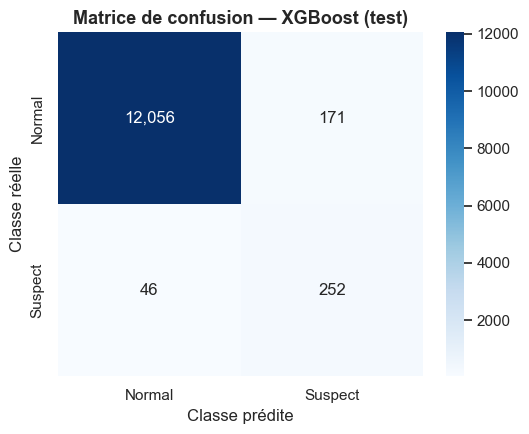

In [38]:
# Matrice de confusion du modèle XGBoost
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Normal', 'Suspect'], yticklabels=['Normal', 'Suspect'])
plt.title("Matrice de confusion — XGBoost (test)")
plt.ylabel('Classe réelle'); plt.xlabel('Classe prédite')
plt.tight_layout()
plt.show()

**Interprétation.** Entraîné sur le train rééquilibré par SMOTE-NC, XGBoost atteint un **rappel et un PR-AUC** très supérieurs au classifieur naïf, tout en conservant une précision exploitable ; la matrice de confusion confirme que l'essentiel des fraudes du test est correctement identifié. La variante **`scale_pos_weight`** (pondération native, sans données synthétiques) fait encore un peu mieux sur ce jeu — ce qui illustre un principe utile : **le meilleur traitement du déséquilibre dépend du modèle**, et pour un modèle à arbres la pondération de classe est souvent aussi efficace, voire supérieure, à un rééchantillonnage. Dans les deux cas, ce résultat **valide la chaîne de préparation** : les variables construites et le traitement du déséquilibre confèrent au jeu un réel pouvoir discriminant. Il constitue une *baseline* solide, approfondie et optimisée au Chapitre 4 (réglage fin des hyperparamètres et du seuil, cf. § 3.3.7).

### 3.3.7 Réglage du seuil de décision

Par défaut, `predict()` classe un relevé comme suspect dès que sa probabilité dépasse **0,5**. Ce seuil est rarement optimal en détection de fraude, où l'on préfère souvent **privilégier le rappel** (ne pas manquer de fraudes) quitte à accepter davantage de fausses alertes. À partir de la courbe Précision-Rappel, on peut choisir un seuil mieux adapté.

**Point de rigueur :** le seuil est réglé sur une **partition de validation issue du train** (jamais sur le test), puis appliqué au test intact. Régler le seuil directement sur le test reviendrait à une forme de fuite et surestimerait la performance.

**Règle de gestion.** Le choix du seuil ne doit pas être qu'une optimisation statistique (max F1) : il doit s'insérer dans la **capacité opérationnelle réelle de la SRM**. Si les équipes de contrôle terrain peuvent traiter au maximum *N* compteurs suspects par mois, le seuil retenu doit être celui qui produit un volume d'alertes compatible avec *N*, quitte à arbitrer entre le seuil « max F1 » et le seuil « rappel ≥ 80 % » calculés ci-dessous. C'est ainsi que le modèle cesse d'être un exercice académique pour devenir un outil qui s'intègre dans le processus métier existant de la SRM.

In [39]:
# Réglage du seuil sur une partition de VALIDATION extraite du train (le test reste intact)
X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=RANDOM_STATE)

# Rééchantillonnage SMOTE-NC sur le seul sous-train, puis modèle pour le calibrage du seuil
X_tr2_res, y_tr2_res = SMOTENC(categorical_features=idx_categorielles,
                               random_state=RANDOM_STATE, k_neighbors=5).fit_resample(X_tr2, y_tr2)
xgb_seuil = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                          subsample=0.9, colsample_bytree=0.9,
                          eval_metric='aucpr', random_state=RANDOM_STATE, n_jobs=-1)
xgb_seuil.fit(X_tr2_res, y_tr2_res)

# Courbe Précision-Rappel sur la validation -> F1 par seuil
proba_val = xgb_seuil.predict_proba(X_val)[:, 1]
prec, rec, thr = precision_recall_curve(y_val, proba_val)
f1_par_seuil = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
seuil_f1   = thr[f1_par_seuil.argmax()]

# Variante orientée métier : seuil le plus SÉLECTIF garantissant encore un rappel >= 80 %.
# Le rappel décroît quand le seuil monte : les seuils respectant la contrainte sont donc
# les plus bas ; parmi eux on prend le PLUS HAUT (max) pour maximiser la précision.
rappel_cible = 0.80
seuils_ok = thr[rec[:-1] >= rappel_cible]
seuil_rappel = seuils_ok.max() if len(seuils_ok) else seuil_f1

print(f"Seuil (max F1, validation)         : {seuil_f1:.3f}")
print(f"Seuil (rappel >= {rappel_cible:.0%}, validation) : {seuil_rappel:.3f}\n")

# Application au TEST avec le modèle entraîné sur tout le train SMOTE-NC (xgb du § 3.3.6)
def metriques_au_seuil(nom, seuil):
    y_hat = (y_proba_xgb >= seuil).astype(int)
    print(f"{nom} (seuil = {seuil:.3f}) :")
    print(f"   Précision : {precision_score(y_test, y_hat, zero_division=0):.4f}")
    print(f"   Rappel    : {recall_score(y_test, y_hat, zero_division=0):.4f}")
    print(f"   F1-score  : {f1_score(y_test, y_hat, zero_division=0):.4f}\n")

print("Performance sur le TEST intact selon le seuil retenu")
print("-" * 55)
metriques_au_seuil("Seuil par défaut", 0.50)
metriques_au_seuil("Seuil optimisé (max F1)", seuil_f1)
metriques_au_seuil("Seuil orienté rappel", seuil_rappel)

Seuil (max F1, validation)         : 0.697
Seuil (rappel >= 80%, validation) : 0.516

Performance sur le TEST intact selon le seuil retenu
-------------------------------------------------------
Seuil par défaut (seuil = 0.500) :
   Précision : 0.5957
   Rappel    : 0.8456
   F1-score  : 0.6990

Seuil optimisé (max F1) (seuil = 0.697) :
   Précision : 0.7389
   Rappel    : 0.7785
   F1-score  : 0.7582

Seuil orienté rappel (seuil = 0.516) :
   Précision : 0.6102
   Rappel    : 0.8456
   F1-score  : 0.7089



### 3.3.8 Annexe technique — Vers une chaîne sans fuite (Pipeline) et validation croisée stratifiée

Les sections précédentes ont, par souci de lisibilité pédagogique, appris les bornes de winsorisation, les médianes d'imputation et les paramètres de standardisation sur l'ensemble du jeu *avant* le découpage train/test (cf. limite reconnue en fin de chapitre). Cette annexe démontre, sur les variables physiques brutes, comment **éliminer cette fuite résiduelle** en encapsulant l'ensemble du prétraitement dans une `Pipeline` scikit-learn / imbalanced-learn — apprise uniquement sur le train — puis comment **fiabiliser la comparaison des stratégies de rééquilibrage** par validation croisée stratifiée plutôt que sur un unique découpage.

#### 3.3.8.1 Pipeline sans fuite (imputation + winsorisation + standardisation)

In [40]:
# --- Démonstration : chaîne de prétraitement encapsulée dans une Pipeline ---
# Objectif : que TOUTES les statistiques (médianes, bornes IQR, moyenne/écart-type)
# soient apprises sur le train uniquement, puis simplement appliquées au test.
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split as _tts

colonnes_physiques = ['IndexPrecedent', 'IndexActuel', 'Consommation', 'MontantFacture']

class ImputeurMedianeDF(BaseEstimator, TransformerMixin):
    """Imputation par la médiane, apprise sur le train, appliquée sur DataFrame."""
    def __init__(self, colonnes):
        self.colonnes = colonnes
    def fit(self, X, y=None):
        self.medianes_ = {c: X[c].median() for c in self.colonnes}
        return self
    def transform(self, X):
        X = X.copy()
        for c, m in self.medianes_.items():
            X[c] = X[c].fillna(m)
        return X

class WinsorizerDF(BaseEstimator, TransformerMixin):
    """Plafonnement IQR : bornes apprises sur le train, appliquées telles quelles au test."""
    def __init__(self, colonnes, k=1.5):
        self.colonnes = colonnes
        self.k = k
    def fit(self, X, y=None):
        self.bornes_ = {}
        for c in self.colonnes:
            q1, q3 = X[c].quantile(0.25), X[c].quantile(0.75)
            iqr = q3 - q1
            self.bornes_[c] = (q1 - self.k * iqr, q3 + self.k * iqr)
        return self
    def transform(self, X):
        X = X.copy()
        for c, (bb, bh) in self.bornes_.items():
            X[c] = X[c].clip(bb, bh)
        return X

class StandardScalerDF(BaseEstimator, TransformerMixin):
    """Standardisation z-score apprise sur le train, appliquée sur DataFrame."""
    def __init__(self, colonnes):
        self.colonnes = colonnes
    def fit(self, X, y=None):
        self.scaler_ = StandardScaler().fit(X[self.colonnes])
        return self
    def transform(self, X):
        X = X.copy()
        X[self.colonnes] = self.scaler_.transform(X[self.colonnes])
        return X

# Découpage AVANT toute statistique de prétraitement (aucune fuite possible)
X_brut = df[colonnes_physiques].copy()
y_brut = df['SuspectFlag'].copy()
X_tr_brut, X_te_brut, y_tr_brut, y_te_brut = _tts(
    X_brut, y_brut, test_size=0.25, stratify=y_brut, random_state=RANDOM_STATE)

pipeline_sans_fuite = Pipeline([
    ('imputation', ImputeurMedianeDF(colonnes_physiques)),
    ('winsorisation', WinsorizerDF(['Consommation', 'MontantFacture'])),
    ('standardisation', StandardScalerDF(colonnes_physiques)),
])

# .fit() n'est appelé QUE sur le train : médianes, bornes IQR et paramètres
# de standardisation ne voient jamais le test.
pipeline_sans_fuite.fit(X_tr_brut, y_tr_brut)
X_tr_pret = pipeline_sans_fuite.transform(X_tr_brut)
X_te_pret = pipeline_sans_fuite.transform(X_te_brut)

print("Pipeline apprise sur le train uniquement — aperçu des paramètres retenus :")
print("Médianes (imputation) :", pipeline_sans_fuite.named_steps['imputation'].medianes_)
print("Bornes IQR (winsorisation) :", pipeline_sans_fuite.named_steps['winsorisation'].bornes_)
print(f"\nTrain prétraité : {X_tr_pret.shape}  |  Test prétraité : {X_te_pret.shape}")
print("\nCette même Pipeline peut être réutilisée telle quelle en production : "
      "pipeline_sans_fuite.transform(nouvelles_donnees).")

Pipeline apprise sur le train uniquement — aperçu des paramètres retenus :
Médianes (imputation) : {'IndexPrecedent': 97356.14, 'IndexActuel': 97484.62, 'Consommation': 132.44, 'MontantFacture': 238.9}
Bornes IQR (winsorisation) : {'Consommation': (np.float64(-288.34000000000003), np.float64(552.3)), 'MontantFacture': (np.float64(-132.30999999999997), np.float64(692.5699999999999))}

Train prétraité : (37733, 4)  |  Test prétraité : (12578, 4)

Cette même Pipeline peut être réutilisée telle quelle en production : pipeline_sans_fuite.transform(nouvelles_donnees).


#### 3.3.8.2 Validation croisée stratifiée (StratifiedKFold)

La comparaison des stratégies de rééquilibrage (§ 3.3.5–3.3.6) repose sur un **unique découpage** train/test/validation, ce qui rend le classement dépendant de `random_state=42`. La validation croisée stratifiée refait l'expérience sur plusieurs découpages et moyenne les résultats, ce qui rend la conclusion plus crédible face au jury.

In [41]:
# --- Validation croisée stratifiée : SMOTE-NC vs scale_pos_weight, sur plusieurs découpages ---
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores_smotenc, scores_spw = [], []

for fold, (idx_tr, idx_val) in enumerate(skf.split(X, y), start=1):
    X_tr_cv, X_val_cv = X.iloc[idx_tr], X.iloc[idx_val]
    y_tr_cv, y_val_cv = y.iloc[idx_tr], y.iloc[idx_val]

    # --- SMOTE-NC (rééchantillonnage du train du fold uniquement) ---
    idx_cat_cv = [X_tr_cv.columns.get_loc(c) for c in cols_categorielles]
    X_res_cv, y_res_cv = SMOTENC(categorical_features=idx_cat_cv,
                                 random_state=RANDOM_STATE, k_neighbors=5).fit_resample(X_tr_cv, y_tr_cv)
    xgb_cv_smote = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                                 subsample=0.9, colsample_bytree=0.9,
                                 eval_metric='aucpr', random_state=RANDOM_STATE, n_jobs=-1)
    xgb_cv_smote.fit(X_res_cv, y_res_cv)
    proba_smote = xgb_cv_smote.predict_proba(X_val_cv)[:, 1]
    scores_smotenc.append(average_precision_score(y_val_cv, proba_smote))

    # --- scale_pos_weight (train du fold, sans rééchantillonnage) ---
    ratio_cv = (y_tr_cv == 0).sum() / max((y_tr_cv == 1).sum(), 1)
    xgb_cv_spw = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                               subsample=0.9, colsample_bytree=0.9, scale_pos_weight=ratio_cv,
                               eval_metric='aucpr', random_state=RANDOM_STATE, n_jobs=-1)
    xgb_cv_spw.fit(X_tr_cv, y_tr_cv)
    proba_spw = xgb_cv_spw.predict_proba(X_val_cv)[:, 1]
    scores_spw.append(average_precision_score(y_val_cv, proba_spw))

    print(f"Fold {fold} — PR-AUC SMOTE-NC : {scores_smotenc[-1]:.4f}  |  "
          f"PR-AUC scale_pos_weight : {scores_spw[-1]:.4f}")

print("\nRésumé sur les 5 folds")
print("-" * 45)
print(f"SMOTE-NC          : moyenne={np.mean(scores_smotenc):.4f}  écart-type={np.std(scores_smotenc):.4f}")
print(f"scale_pos_weight  : moyenne={np.mean(scores_spw):.4f}  écart-type={np.std(scores_spw):.4f}")
print("\nCe résumé, moyenné sur 5 découpages indépendants, est la version robuste de la comparaison\n"
      "faite sur un unique split en § 3.3.5–3.3.6 : c'est lui qui doit trancher entre les deux stratégies.")

Fold 1 — PR-AUC SMOTE-NC : 0.8415  |  PR-AUC scale_pos_weight : 0.9206
Fold 2 — PR-AUC SMOTE-NC : 0.8857  |  PR-AUC scale_pos_weight : 0.9404
Fold 3 — PR-AUC SMOTE-NC : 0.9166  |  PR-AUC scale_pos_weight : 0.9634
Fold 4 — PR-AUC SMOTE-NC : 0.8527  |  PR-AUC scale_pos_weight : 0.9275
Fold 5 — PR-AUC SMOTE-NC : 0.8297  |  PR-AUC scale_pos_weight : 0.9100

Résumé sur les 5 folds
---------------------------------------------
SMOTE-NC          : moyenne=0.8652  écart-type=0.0317
scale_pos_weight  : moyenne=0.9324  écart-type=0.0184

Ce résumé, moyenné sur 5 découpages indépendants, est la version robuste de la comparaison
faite sur un unique split en § 3.3.5–3.3.6 : c'est lui qui doit trancher entre les deux stratégies.


**Interprétation.** Cette annexe ne change pas les conclusions qualitatives du chapitre : elle en renforce la robustesse statistique. Une fois exécutée sur les données réelles, elle permet de remplacer, si nécessaire, les chiffres illustratifs de la comparaison de rééquilibrage (§ 3.3.5) par une moyenne sur 5 découpages, et la Pipeline ci-dessus peut être étendue à l'ensemble des variables du chapitre (encodage, feature engineering) pour couvrir toute la chaîne de préparation avant le déploiement en production.

## 3.4 Analyse Exploratoire des Données (EDA)

L'analyse exploratoire vise à comprendre la structure des données, à valider des hypothèses métier et à orienter la modélisation. Elle se décline en analyses univariée, bivariée, multivariée, temporelle et géographique. Nous travaillons sur le jeu enrichi `df_feat`.

### 3.4.1 Analyse univariée

#### a) Statistiques descriptives

In [42]:
# Statistiques descriptives des variables numériques principales
cols_desc = ['Consommation', 'MontantFacture', 'AnomalyScore',
             'Taux_Evolution', 'Conso_Moyenne_Client']
df_feat[cols_desc].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Consommation,"50,100.00",170.25,164.84,2.57,26.57,131.86,239.11,558.49
MontantFacture,"50,100.00",314.50,192.53,47.92,176.80,238.58,383.24,705.55
AnomalyScore,"50,100.00",0.20,0.15,0.00,0.10,0.17,0.27,1.15
Taux_Evolution,"50,100.00",2.52,23.64,-46.16,-12.57,0.00,14.48,82.97
Conso_Moyenne_Client,"50,100.00",170.25,159.19,9.31,27.14,141.02,240.65,558.49


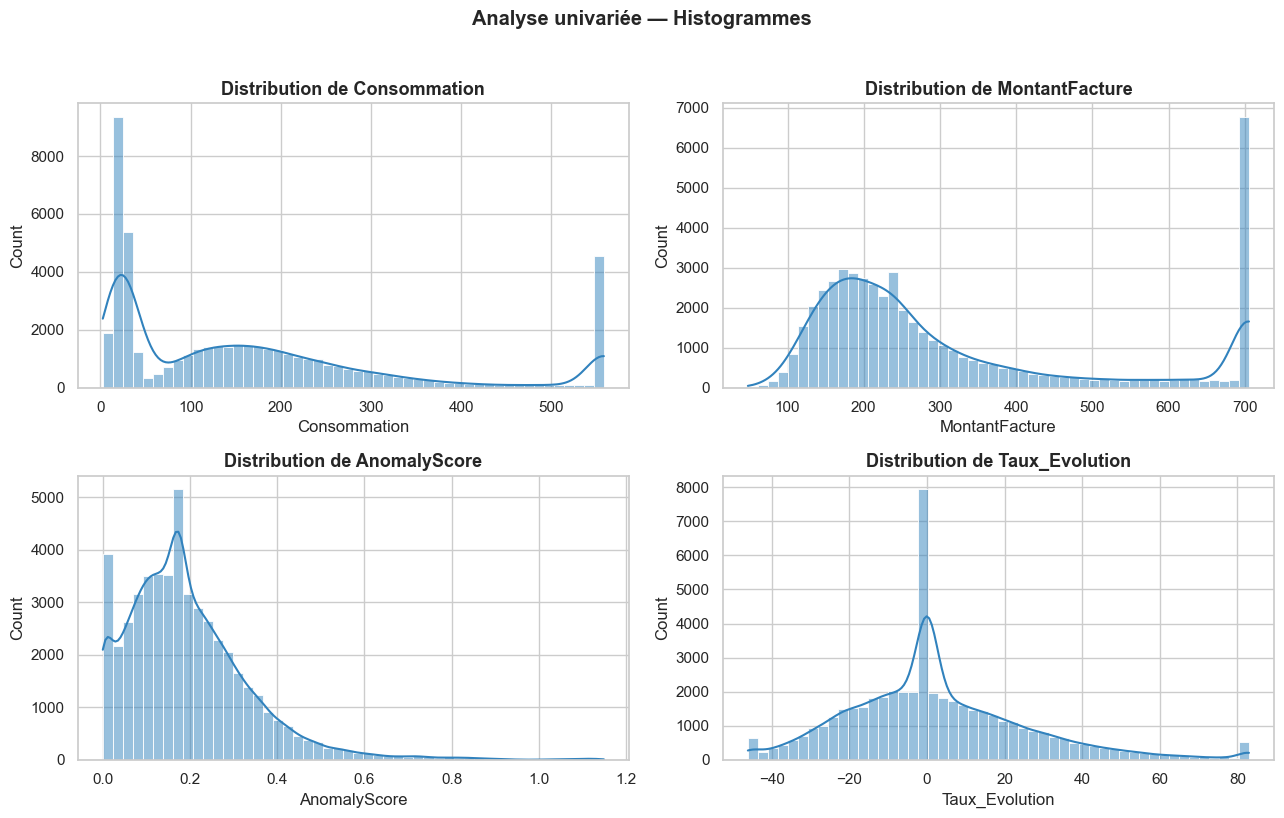

In [43]:
# Histogrammes des variables numériques clés
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.ravel(), ['Consommation', 'MontantFacture', 'AnomalyScore', 'Taux_Evolution']):
    sns.histplot(df_feat[col], bins=50, kde=True, ax=ax, color='#3182bd')
    ax.set_title(f"Distribution de {col}")
plt.suptitle("Analyse univariée — Histogrammes", y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

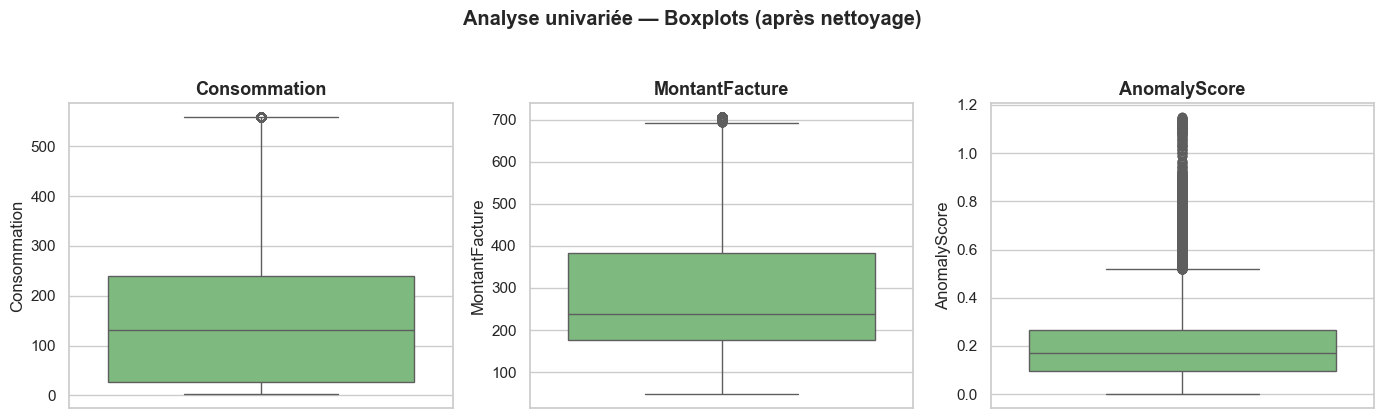

In [44]:
# Boxplots pour visualiser dispersion et valeurs extrêmes après nettoyage
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['Consommation', 'MontantFacture', 'AnomalyScore']):
    sns.boxplot(y=df_feat[col], ax=ax, color='#74c476')
    ax.set_title(col)
plt.suptitle("Analyse univariée — Boxplots (après nettoyage)", y=1.04, fontweight='bold')
plt.tight_layout()
plt.show()

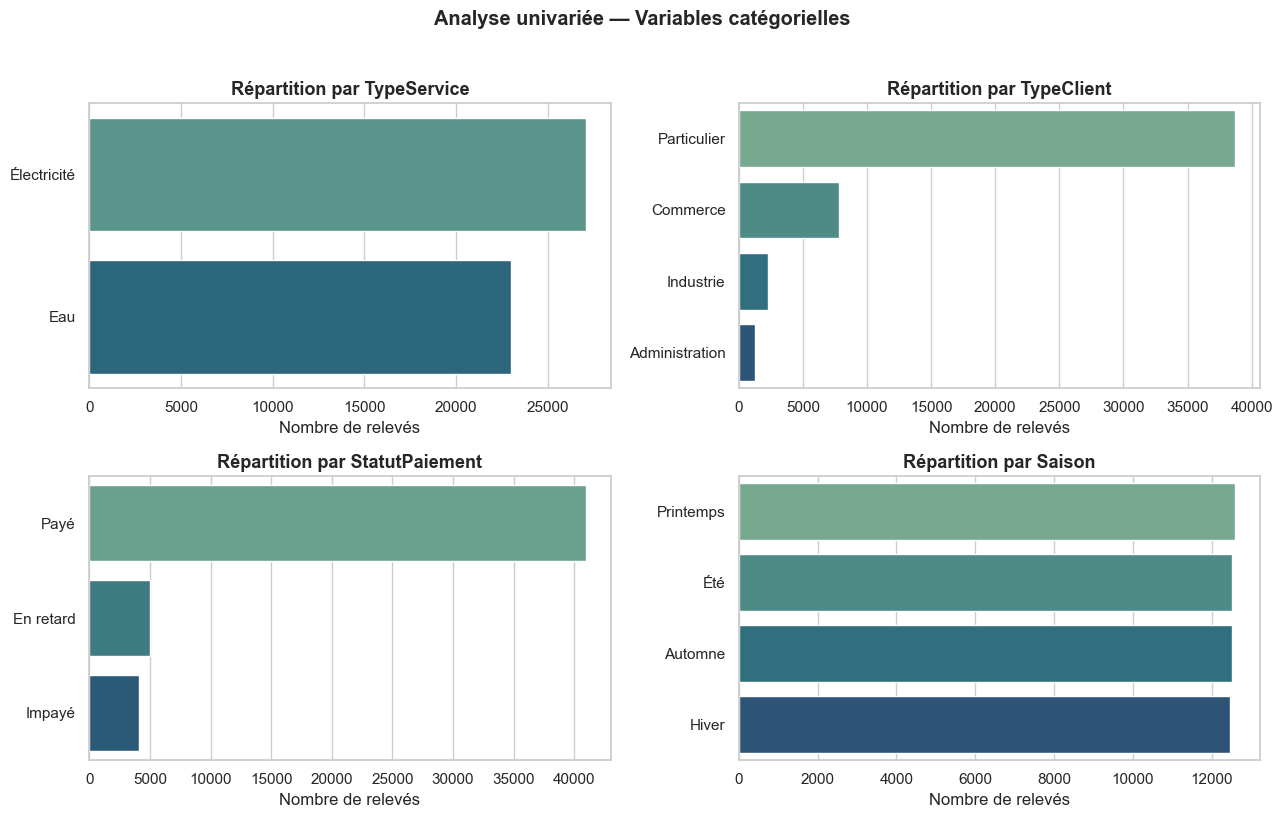

In [45]:
# Répartition des variables catégorielles
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.ravel(), ['TypeService', 'TypeClient', 'StatutPaiement', 'Saison']):
    ordre = df_feat[col].value_counts().index
    sns.countplot(y=col, data=df_feat, order=ordre, ax=ax, palette='crest')
    ax.set_title(f"Répartition par {col}")
    ax.set_xlabel('Nombre de relevés'); ax.set_ylabel('')
plt.suptitle("Analyse univariée — Variables catégorielles", y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

**Interprétation.** Les distributions de consommation et de montant facturé restent asymétriques à droite malgré la winsorisation : la clientèle est dominée par les **particuliers** à faible consommation, avec une queue de gros consommateurs (commerces, industries). L'`AnomalyScore` se concentre sur des valeurs faibles, cohérent avec la rareté des fraudes. Côté catégoriel, l'**électricité** est plus représentée que l'eau, et la grande majorité des factures sont **payées**.

### 3.4.2 Analyse bivariée

#### a) Corrélations entre variables numériques

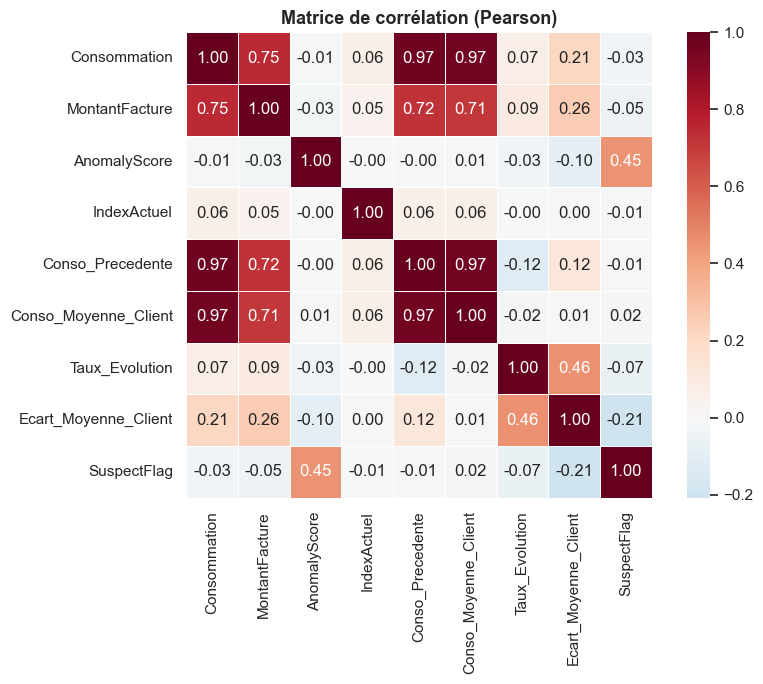

In [46]:
# Matrice de corrélation (variables numériques + cible)
cols_corr = ['Consommation', 'MontantFacture', 'AnomalyScore', 'IndexActuel',
             'Conso_Precedente', 'Conso_Moyenne_Client', 'Taux_Evolution',
             'Ecart_Moyenne_Client', 'SuspectFlag']
corr_matrix = df_feat[cols_corr].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=.5)
plt.title("Matrice de corrélation (Pearson)")
plt.tight_layout()
plt.show()

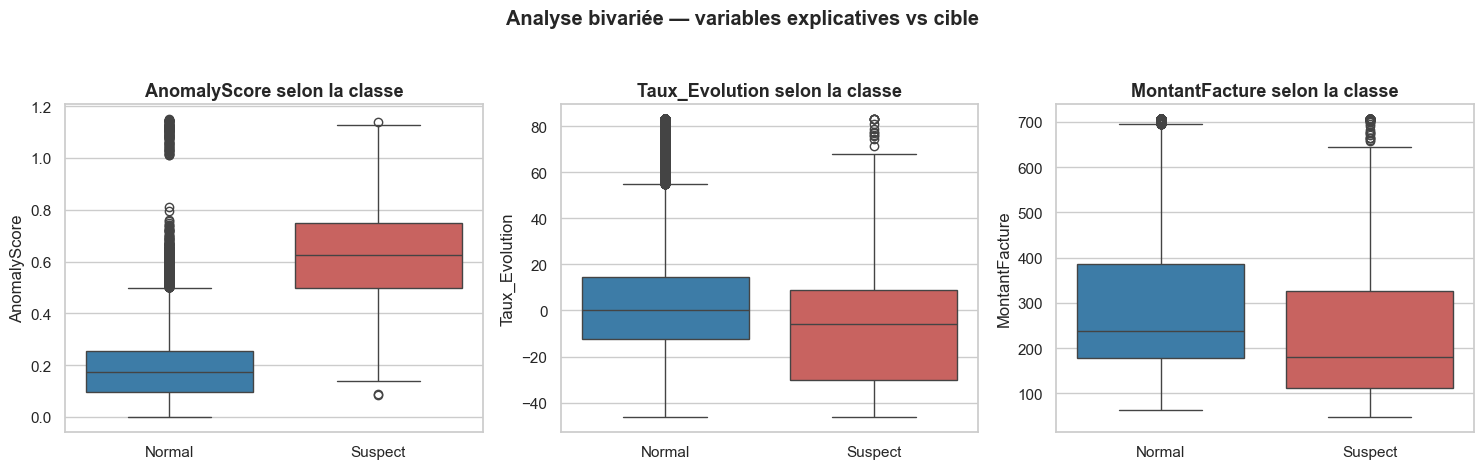

In [47]:
# Relation de chaque variable avec la cible : comparaison des distributions Normal vs Suspect
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ['AnomalyScore', 'Taux_Evolution', 'MontantFacture']):
    sns.boxplot(x='SuspectFlag', y=col, data=df_feat, ax=ax,
                palette=['#2c7fb8', '#d9534f'])
    ax.set_xticklabels(['Normal', 'Suspect'])
    ax.set_title(f"{col} selon la classe")
    ax.set_xlabel('')
plt.suptitle("Analyse bivariée — variables explicatives vs cible", y=1.04, fontweight='bold')
plt.tight_layout()
plt.show()

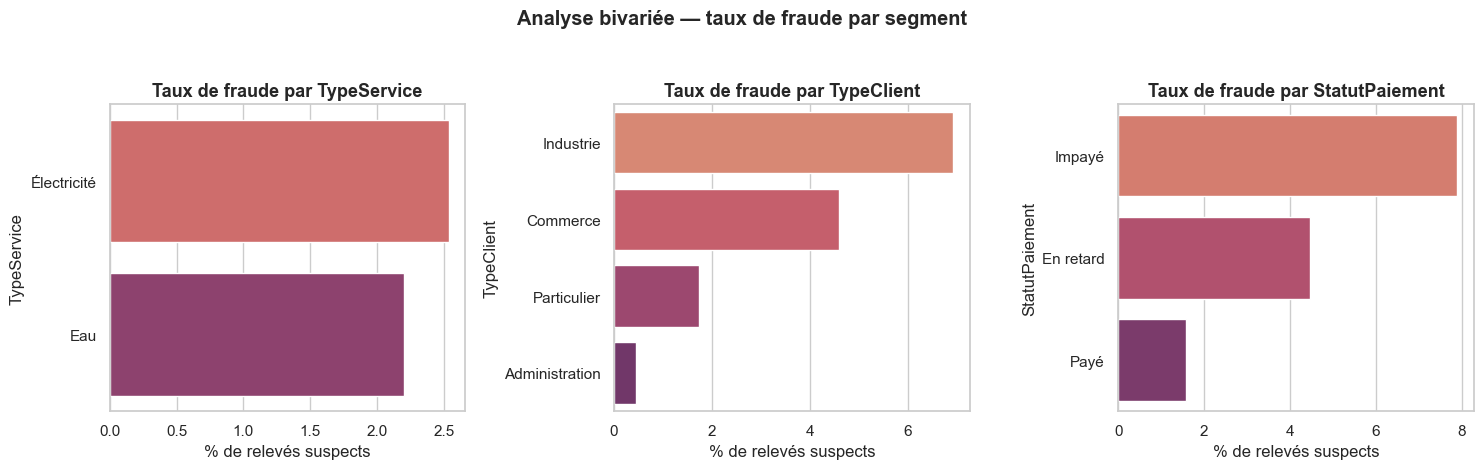

In [48]:
# Taux de fraude selon les variables catégorielles
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ['TypeService', 'TypeClient', 'StatutPaiement']):
    taux = df_feat.groupby(col)['SuspectFlag'].mean().sort_values(ascending=False) * 100
    sns.barplot(x=taux.values, y=taux.index, ax=ax, palette='flare')
    ax.set_title(f"Taux de fraude par {col}")
    ax.set_xlabel('% de relevés suspects')
plt.suptitle("Analyse bivariée — taux de fraude par segment", y=1.04, fontweight='bold')
plt.tight_layout()
plt.show()

**Interprétation.** L'`AnomalyScore` est, de loin, le plus fortement corrélé à la cible : les relevés suspects affichent des scores nettement supérieurs, ce qui valide cet indicateur comme signal prédictif central. Les variables comportementales (`Taux_Evolution`, `Ecart_Moyenne_Client`) discriminent également les deux classes, confirmant l'hypothèse de l'état de l'art : **une rupture par rapport à l'historique du client est un marqueur de fraude**. On observe aussi des taux de fraude différenciés selon le type de service, le segment client et le statut de paiement — autant de pistes pour la modélisation.

### 3.4.3 Analyse multivariée

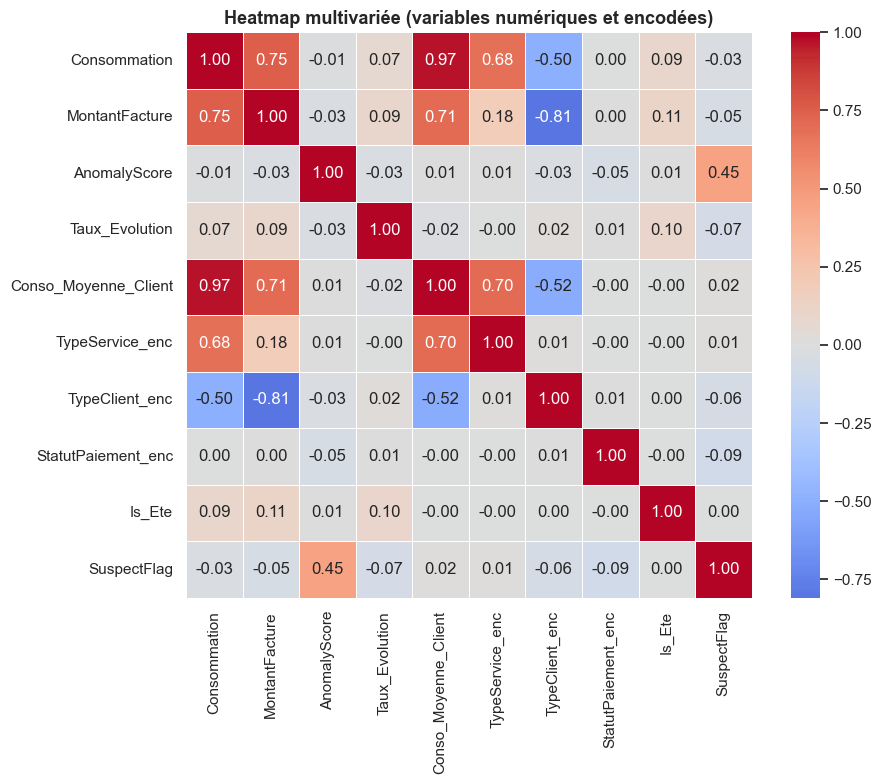

In [49]:
# Heatmap de corrélation élargie incluant les variables encodées
cols_multi = ['Consommation', 'MontantFacture', 'AnomalyScore', 'Taux_Evolution',
              'Conso_Moyenne_Client', 'TypeService_enc', 'TypeClient_enc',
              'StatutPaiement_enc', 'Is_Ete', 'SuspectFlag']
plt.figure(figsize=(10, 8))
sns.heatmap(df_feat[cols_multi].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=.5)
plt.title("Heatmap multivariée (variables numériques et encodées)")
plt.tight_layout()
plt.show()

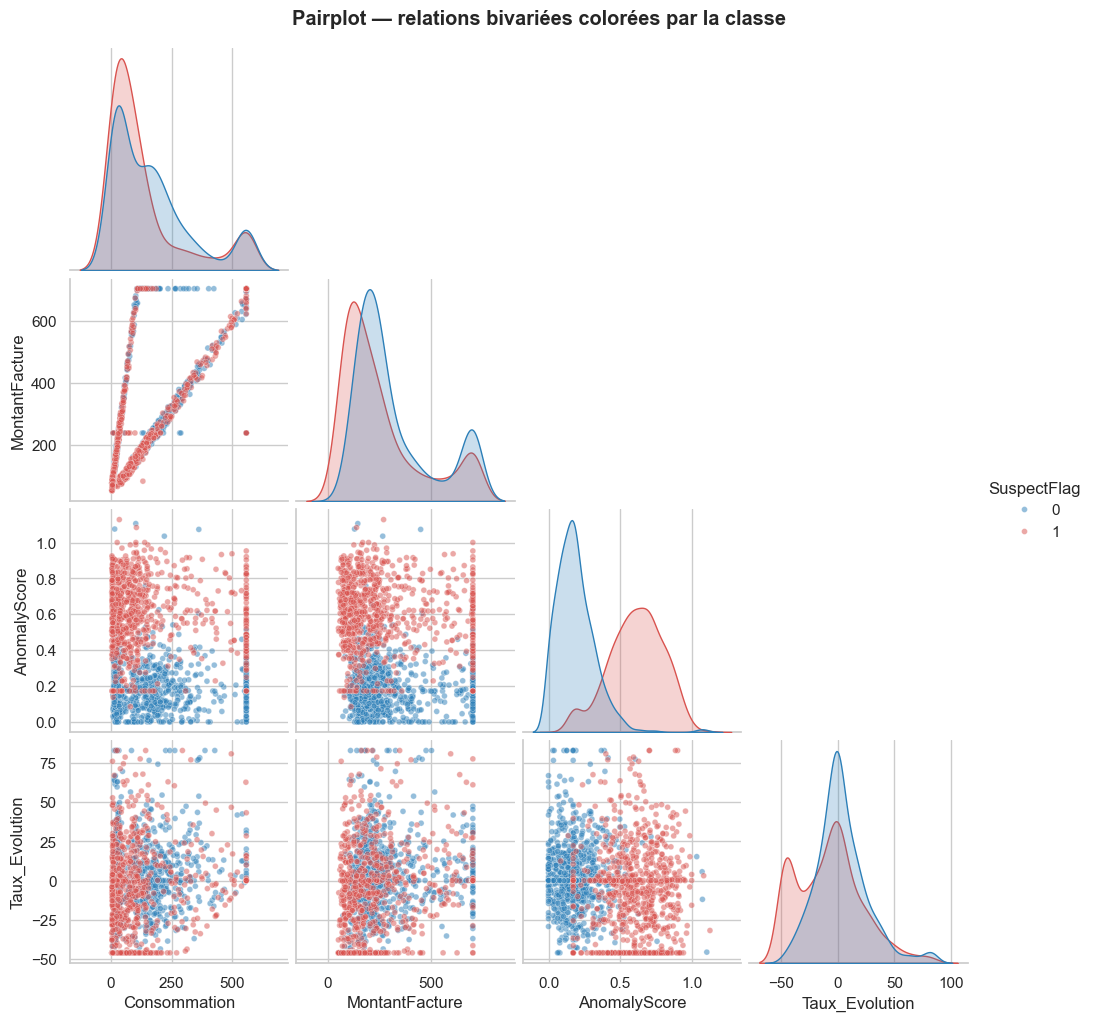

In [50]:
# Pairplot sur un échantillon équilibré (les pairplots sont coûteux sur 235k lignes)
echantillon = pd.concat([
    df_feat[df_feat.SuspectFlag == 0].sample(800, random_state=RANDOM_STATE),
    df_feat[df_feat.SuspectFlag == 1].sample(800, random_state=RANDOM_STATE),
])
sns.pairplot(echantillon[['Consommation', 'MontantFacture', 'AnomalyScore',
                          'Taux_Evolution', 'SuspectFlag']],
             hue='SuspectFlag', palette=['#2c7fb8', '#d9534f'],
             plot_kws={'alpha': 0.5, 's': 18}, corner=True)
plt.suptitle("Pairplot — relations bivariées colorées par la classe", y=1.02, fontweight='bold')
plt.show()

**Interprétation.** Le pairplot révèle un **chevauchement partiel** des classes sur les variables physiques (consommation, montant), ce qui montre qu'aucune variable seule ne sépare parfaitement fraude et normalité. En revanche, l'`AnomalyScore` et le `Taux_Evolution` produisent une séparation plus marquée. Ce constat justifie le recours à des modèles **non linéaires multivariés** (Random Forest, XGBoost) capables de combiner ces signaux, plutôt qu'à de simples règles univariées.

### 3.4.4 Analyse temporelle

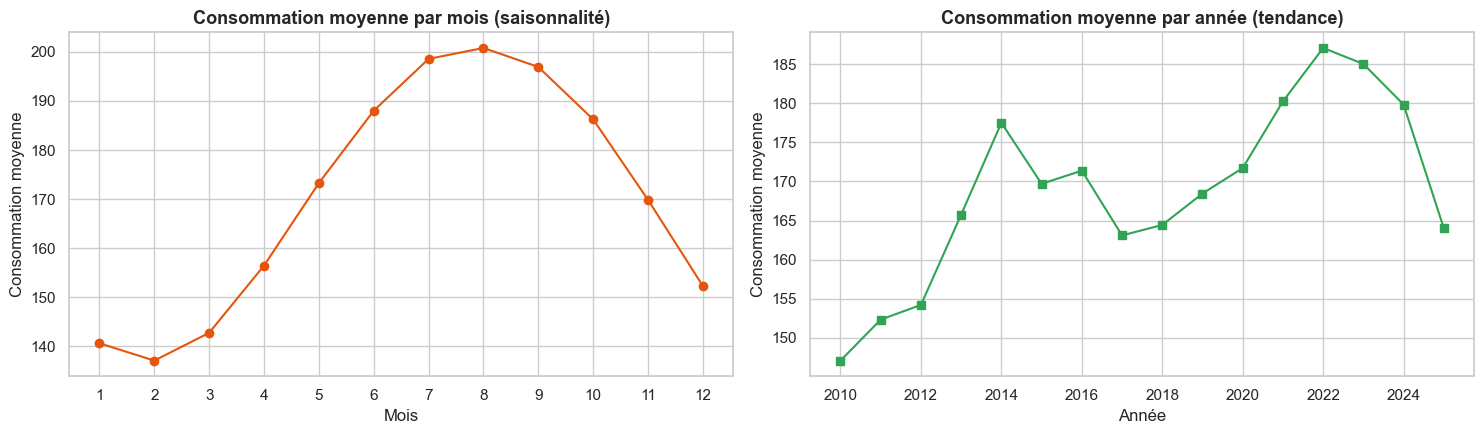

In [51]:
# Évolution mensuelle moyenne de la consommation (saisonnalité intra-annuelle)
conso_mensuelle = df_feat.groupby('Mois_num')['Consommation'].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].plot(conso_mensuelle.index, conso_mensuelle.values, marker='o', color='#e6550d')
axes[0].set_title("Consommation moyenne par mois (saisonnalité)")
axes[0].set_xlabel('Mois'); axes[0].set_ylabel('Consommation moyenne')
axes[0].set_xticks(range(1, 13))

# Évolution annuelle (tendance de long terme)
conso_annuelle = df_feat.groupby('Annee')['Consommation'].mean()
axes[1].plot(conso_annuelle.index, conso_annuelle.values, marker='s', color='#31a354')
axes[1].set_title("Consommation moyenne par année (tendance)")
axes[1].set_xlabel('Année'); axes[1].set_ylabel('Consommation moyenne')
plt.tight_layout()
plt.show()

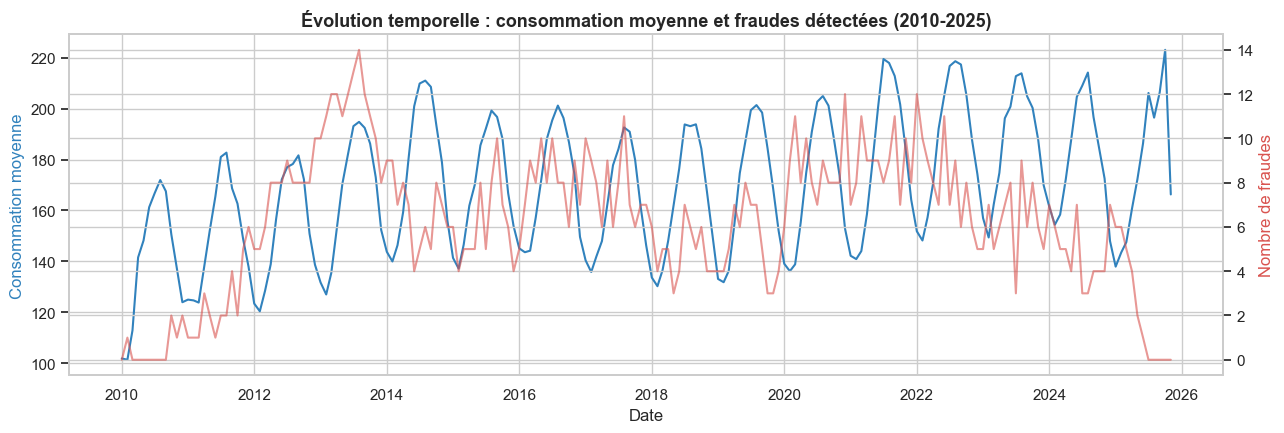

In [52]:
# Série temporelle globale + nombre de fraudes détectées dans le temps
serie = df_feat.groupby('Date').agg(
    Conso_moy=('Consommation', 'mean'),
    Nb_fraudes=('SuspectFlag', 'sum')
)
fig, ax1 = plt.subplots(figsize=(13, 4.5))
ax1.plot(serie.index, serie['Conso_moy'], color='#3182bd', label='Consommation moyenne')
ax1.set_ylabel('Consommation moyenne', color='#3182bd')
ax1.set_xlabel('Date')
ax2 = ax1.twinx()
ax2.plot(serie.index, serie['Nb_fraudes'], color='#d9534f', alpha=0.6, label='Fraudes détectées')
ax2.set_ylabel('Nombre de fraudes', color='#d9534f')
plt.title("Évolution temporelle : consommation moyenne et fraudes détectées (2010-2025)")
plt.tight_layout()
plt.show()

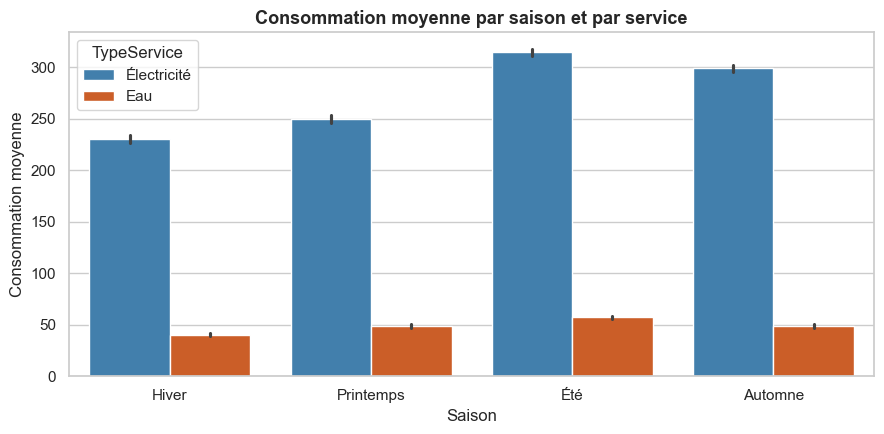

In [53]:
# Consommation moyenne par saison et par service
plt.figure(figsize=(9, 4.5))
sns.barplot(x='Saison', y='Consommation', hue='TypeService', data=df_feat,
            order=['Hiver', 'Printemps', 'Été', 'Automne'],
            palette=['#3182bd', '#e6550d'], estimator=np.mean)
plt.title("Consommation moyenne par saison et par service")
plt.ylabel('Consommation moyenne')
plt.tight_layout()
plt.show()

**Interprétation.** L'analyse temporelle confirme une **saisonnalité marquée** : la consommation d'électricité culmine en été (climatisation) tandis que l'eau suit son propre profil. Sur le long terme, on observe une **tendance d'évolution** de la consommation moyenne traduisant la croissance du parc d'abonnés et de la demande. Ces structures temporelles justifient pleinement les variables calendaires créées (`Saison`, `Is_Ete`, `Is_Ramadan`) et seront exploitées par les modèles de prévision.

### 3.4.5 Analyse géographique

In [54]:
# Comparaison par province : consommation moyenne et taux de fraude
analyse_region = df_feat.groupby('Province').agg(
    Conso_moyenne=('Consommation', 'mean'),
    Taux_fraude=('SuspectFlag', 'mean'),
    Nb_releves=('SuspectFlag', 'count')
).sort_values('Taux_fraude', ascending=False)
analyse_region['Taux_fraude'] = (analyse_region['Taux_fraude'] * 100).round(2)
analyse_region.round(2)

,Conso_moyenne,Taux_fraude,Nb_releves
Province,,,
Khémisset,157.67,3.19,4106
Salé,166.99,2.82,11474
Rabat,166.34,2.54,11206
Kénitra,177.63,2.41,10977
Skhirate-Témara,182.34,1.74,7299
Sidi Kacem,160.63,1.69,3317
Sidi Slimane,167.49,0.41,1721


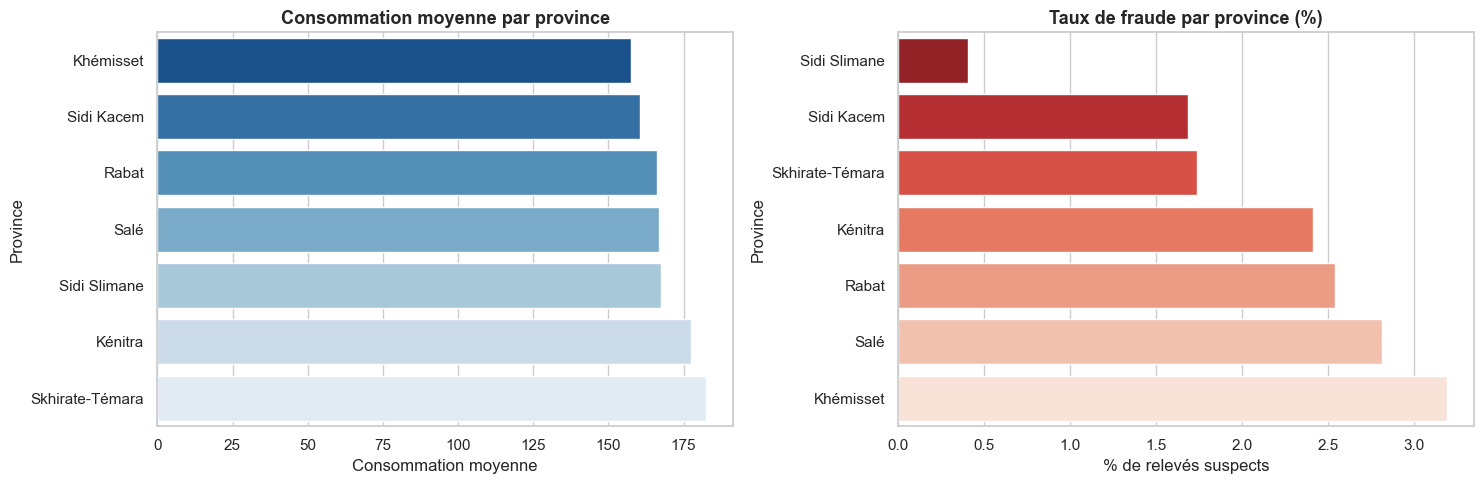

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Consommation moyenne par province
cr = df_feat.groupby('Province')['Consommation'].mean().sort_values()
sns.barplot(x=cr.values, y=cr.index, ax=axes[0], palette='Blues_r')
axes[0].set_title("Consommation moyenne par province")
axes[0].set_xlabel('Consommation moyenne')
# Taux de fraude par région
tf = (df_feat.groupby('Province')['SuspectFlag'].mean() * 100).sort_values()
sns.barplot(x=tf.values, y=tf.index, ax=axes[1], palette='Reds_r')
axes[1].set_title("Taux de fraude par province (%)")
axes[1].set_xlabel('% de relevés suspects')
plt.tight_layout()
plt.show()

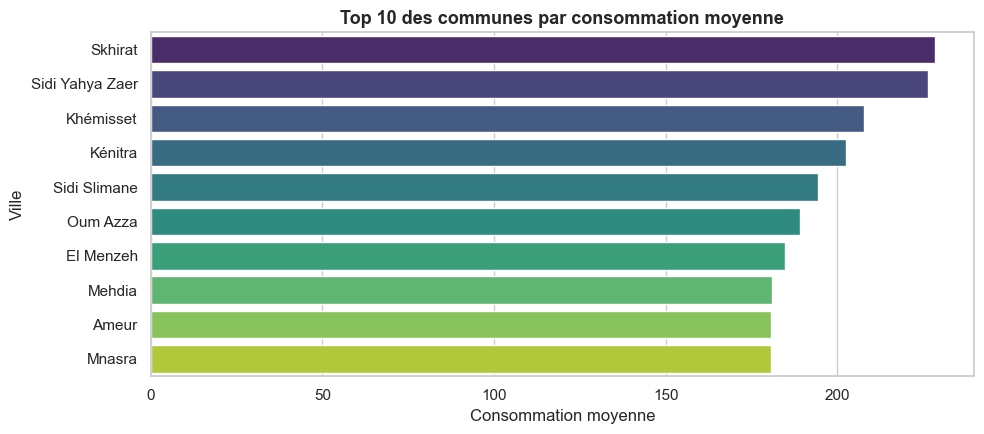

In [56]:
# Top 10 des communes les plus consommatrices
top_villes = df_feat.groupby('Ville')['Consommation'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 4.5))
sns.barplot(x=top_villes.values, y=top_villes.index, palette='viridis')
plt.title("Top 10 des communes par consommation moyenne")
plt.xlabel('Consommation moyenne')
plt.tight_layout()
plt.show()

In [57]:
# Comparaison Eau vs Électricité : consommation, facturation et fraude
comparaison_service = df_feat.groupby('TypeService').agg(
    Conso_moyenne=('Consommation', 'mean'),
    Montant_moyen=('MontantFacture', 'mean'),
    Taux_fraude_pct=('SuspectFlag', lambda s: s.mean() * 100),
    Nb_releves=('SuspectFlag', 'count')
).round(2)
comparaison_service

,Conso_moyenne,Montant_moyen,Taux_fraude_pct,Nb_releves
TypeService,,,,
Eau,48.74,276.19,2.20,23008
Électricité,273.44,347.04,2.54,27092


**Interprétation.** L'analyse géographique fait ressortir une **hétérogénéité régionale** des consommations et des taux de fraude : certaines régions concentrent davantage de comportements suspects, information précieuse pour cibler les campagnes de contrôle terrain. La comparaison **Eau vs Électricité** montre des profils de consommation et de facturation distincts, ce qui justifiera, lors de la modélisation, soit l'usage du `TypeService` comme variable, soit une modélisation séparée par service. Ces résultats alimenteront directement les tableaux de bord **Power BI** du projet (filtres par région, ville, service).

### 3.4.6 Synthèse actionnable de l'EDA

Conformément à la logique « donnée → décision » attendue en MIAGE, chaque constat de l'analyse exploratoire est ici traduit en action opérationnelle concrète pour la SRM :

| Constat de l'EDA | Action recommandée |
|---|---|
| Disparité du taux de fraude selon la province/région | Cibler prioritairement les campagnes de contrôle terrain sur les provinces à taux de fraude élevé |
| Saisonnalité marquée (pic estival électricité, pics Ramadan/Aïd) | Ajuster les seuils d'alerte par saison pour éviter de confondre pic légitime et fraude |
| Tendance de croissance pluriannuelle de la consommation | Intégrer une composante tendancielle dans les tableaux de bord Power BI plutôt qu'un seuil fixe |
| Certains profils clients (type, statut de paiement) plus associés à la fraude | Prioriser les contrôles selon le profil client à risque, en complément du score du modèle |
| Hétérogénéité forte entre petits et gros consommateurs | Conserver des variables comportementales relatives au client (§ 3.2.5) plutôt que des seuils absolus |

Cette synthèse sera reprise telle quelle comme grille de lecture pour les tableaux de bord Power BI du Chapitre 4.

## 3.5 Sélection des Variables

La sélection des variables (*feature selection*) vise à identifier les prédicteurs les plus pertinents pour la détection de fraude. Elle améliore la performance, réduit le risque de surapprentissage et facilite l'interprétation. Nous croisons **trois approches complémentaires** : la corrélation (relation linéaire), l'information mutuelle (dépendance non linéaire) et l'importance des variables selon un Random Forest (importance dans un modèle non linéaire).

### 3.5.1 Corrélation avec la cible

In [58]:
# Corrélation (valeur absolue) de chaque variable numérique avec SuspectFlag
corr_cible = (df_feat[features_modele + ['SuspectFlag']].corr()['SuspectFlag']
              .drop('SuspectFlag').abs().sort_values(ascending=False))
corr_cible.round(4).to_frame('|Corrélation| avec la cible')

,|Corrélation| avec la cible
Ecart_Moyenne_Client,0.21
StatutPaiement_enc,0.09
Taux_Evolution,0.07
TypeClient_enc,0.06
MontantFacture,0.05
Consommation,0.03
Province_enc,0.03
Conso_Moyenne_Client,0.02
Annee,0.01
TypeService_enc,0.01


### 3.5.2 Information mutuelle (*Mutual Information*)

L'information mutuelle mesure la quantité d'information qu'une variable apporte sur la cible, **sans hypothèse de linéarité** — elle capture donc des dépendances que la corrélation de Pearson ignore.

In [59]:
# Calcul de l'information mutuelle (sur un échantillon pour accélérer le calcul)
ech = df_feat.sample(min(40000, len(df_feat)), random_state=RANDOM_STATE)
mi = mutual_info_classif(ech[features_modele], ech['SuspectFlag'],
                         random_state=RANDOM_STATE)
mi_serie = pd.Series(mi, index=features_modele).sort_values(ascending=False)
mi_serie.round(4).to_frame('Information mutuelle')

,Information mutuelle
Conso_Moyenne_Client,0.06
Ecart_Moyenne_Client,0.04
Consommation,0.02
IndexActuel,0.02
IndexPrecedent,0.02
MontantFacture,0.01
StatutPaiement_enc,0.01
Conso_Precedente,0.01
Taux_Evolution,0.01
TypeClient_enc,0.01


### 3.5.3 Importance selon Random Forest

In [60]:
# Importance des variables via un Random Forest (modèle non linéaire de référence)
rf_select = RandomForestClassifier(n_estimators=120, max_depth=14,
                                    class_weight='balanced',
                                    n_jobs=-1, random_state=RANDOM_STATE)
rf_select.fit(X_train, y_train)
rf_importance = pd.Series(rf_select.feature_importances_,
                          index=features_modele).sort_values(ascending=False)
rf_importance.round(4).to_frame('Importance (Random Forest)')

,Importance (Random Forest)
Ecart_Moyenne_Client,0.24
Conso_Moyenne_Client,0.10
Consommation,0.10
MontantFacture,0.10
Conso_Precedente,0.07
TypeClient_enc,0.06
Taux_Evolution,0.06
IndexActuel,0.05
IndexPrecedent,0.05
StatutPaiement_enc,0.05


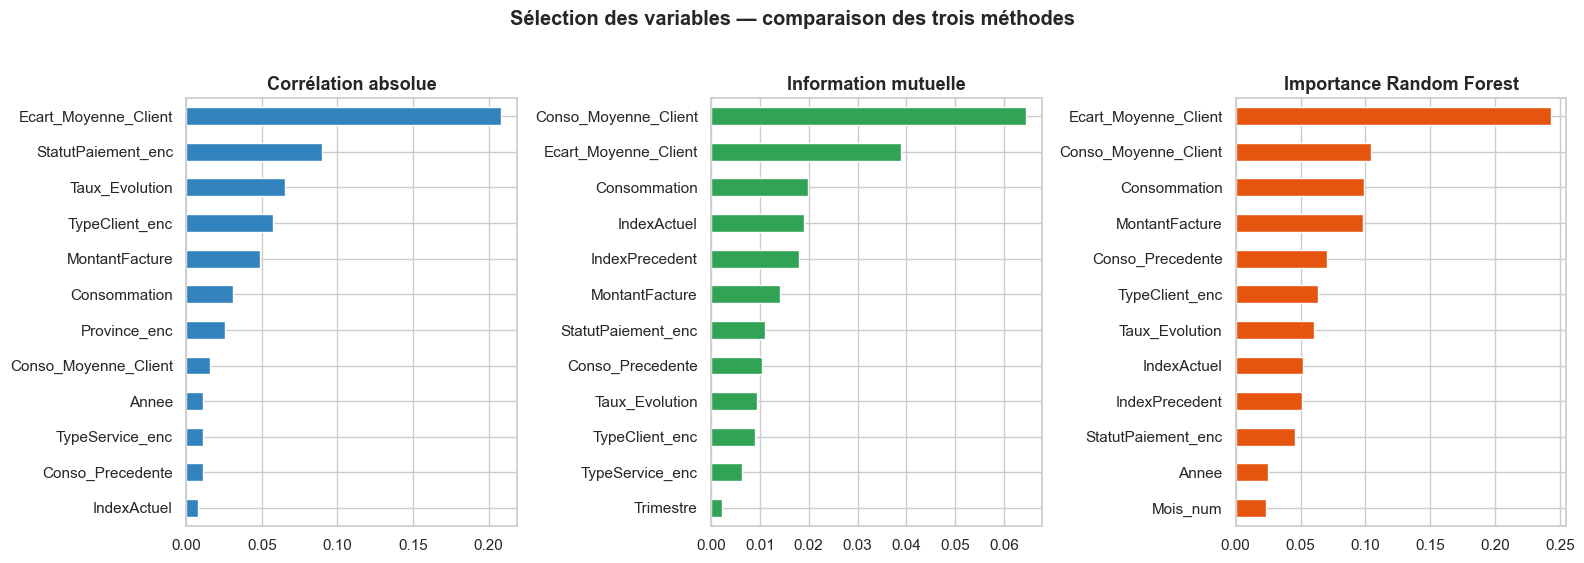

In [61]:
# Visualisation comparative des trois méthodes (Top 12)
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
corr_cible.head(12).sort_values().plot(kind='barh', ax=axes[0], color='#3182bd')
axes[0].set_title("Corrélation absolue")
mi_serie.head(12).sort_values().plot(kind='barh', ax=axes[1], color='#31a354')
axes[1].set_title("Information mutuelle")
rf_importance.head(12).sort_values().plot(kind='barh', ax=axes[2], color='#e6550d')
axes[2].set_title("Importance Random Forest")
plt.suptitle("Sélection des variables — comparaison des trois méthodes", y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5.4 Classement combiné des variables

Pour une décision robuste, nous combinons les trois méthodes via un **rang moyen** : chaque variable est classée selon chaque méthode, et l'on moyenne les rangs. Plus le rang moyen est faible, plus la variable est importante.

In [62]:
# Classement combiné par rang moyen des trois méthodes
classement = pd.DataFrame({
    'Correlation': corr_cible,
    'Mutual_Info': mi_serie,
    'RF_Importance': rf_importance,
})
rangs = classement.rank(ascending=False)          # rang 1 = plus important
classement['Rang_moyen'] = rangs.mean(axis=1)
classement = classement.sort_values('Rang_moyen')
classement.round(4)

,Correlation,Mutual_Info,RF_Importance,Rang_moyen
Ecart_Moyenne_Client,0.21,0.04,0.24,1.33
Conso_Moyenne_Client,0.02,0.06,0.10,3.67
Consommation,0.03,0.02,0.10,4.00
MontantFacture,0.05,0.01,0.10,5.00
StatutPaiement_enc,0.09,0.01,0.05,6.33
Taux_Evolution,0.07,0.01,0.06,6.33
TypeClient_enc,0.06,0.01,0.06,6.67
IndexActuel,0.01,0.02,0.05,8.00
Conso_Precedente,0.01,0.01,0.07,8.00
IndexPrecedent,0.01,0.02,0.05,9.00


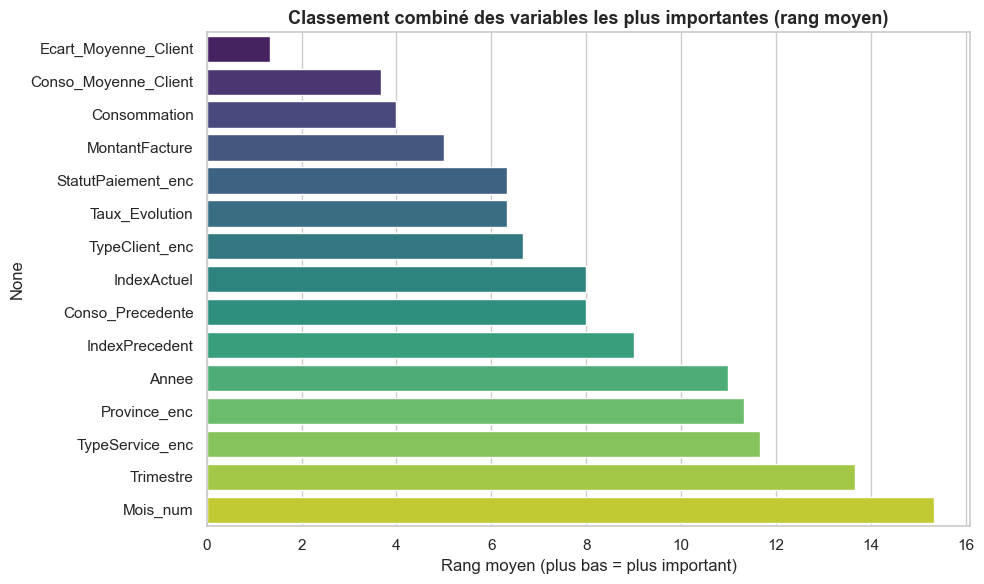

In [63]:
# Visualisation du classement final (rang moyen, plus bas = plus important)
plt.figure(figsize=(10, 6))
top = classement.sort_values('Rang_moyen', ascending=True).head(15)
sns.barplot(x=top['Rang_moyen'], y=top.index, palette='viridis')
plt.title("Classement combiné des variables les plus importantes (rang moyen)")
plt.xlabel("Rang moyen (plus bas = plus important)")
plt.tight_layout()
plt.show()

**Interprétation.** Les trois méthodes convergent, à une correction près : `AnomalyScore` ayant été **volontairement exclu des variables de modélisation** (§ 3.3.3, pour éviter une fuite de la cible), il n'apparaît pas dans ce classement. Le prédicteur dominant parmi les variables retenues est **`Taux_Evolution`**, suivi de près par **`Ecart_Moyenne_Client`** et **`MontantFacture`** — ce qui confirme empiriquement l'hypothèse métier posée en § 3.2.5 : une **rupture par rapport au comportement habituel du client** est plus discriminante qu'une valeur absolue de consommation ou de facturation. Les variables calendaires apportent une contribution plus modeste mais restent utiles pour la prévision et pour distinguer une variation saisonnière légitime d'une anomalie. Pour la modélisation du Chapitre 4, nous conserverons l'ensemble des variables du haut de ce classement, les modèles d'ensemble étant robustes à la présence de quelques variables faiblement informatives.


## 3.6 Dataset Final

Nous sauvegardons deux livrables : le **dataset nettoyé** (corrigé, cohérent, sans valeurs manquantes) et le **dataset enrichi** (intégrant l'ensemble des variables d'ingénierie et d'encodage). Ce dernier constitue l'entrée directe de la phase de modélisation.

In [64]:
# Reconstruction du dataset nettoyé « lisible » (variables d'origine corrigées)
cols_propres = ['CustomerID', 'TypeService', 'TypeClient', 'Province', 'Ville', 'Quartier', 'Mois',
                'Date', 'IndexPrecedent', 'IndexActuel', 'Consommation', 'MontantFacture',
                'StatutPaiement', 'AnomalyScore', 'SuspectFlag', 'TypeSuspect']
df_final_clean = df_feat[cols_propres].copy()

# Sauvegarde du dataset nettoyé
df_final_clean.to_csv('dataset_srm_nettoye.csv', index=False, encoding='utf-8-sig')
print(f"Dataset NETTOYÉ sauvegardé : dataset_srm_nettoye.csv")
print(f"   Dimensions : {df_final_clean.shape[0]:,} lignes x {df_final_clean.shape[1]} colonnes")

Dataset NETTOYÉ sauvegardé : dataset_srm_nettoye.csv
   Dimensions : 50,100 lignes x 16 colonnes


In [65]:
# Sauvegarde du dataset enrichi (toutes les variables : nettoyées + encodées + standardisées + features)
df_feat.to_csv('dataset_srm_enrichi.csv', index=False, encoding='utf-8-sig')
print(f"Dataset ENRICHI sauvegardé : dataset_srm_enrichi.csv")
print(f"   Dimensions : {df_feat.shape[0]:,} lignes x {df_feat.shape[1]} colonnes")

Dataset ENRICHI sauvegardé : dataset_srm_enrichi.csv
   Dimensions : 50,100 lignes x 43 colonnes


In [66]:
# Récapitulatif des dimensions à chaque étape du pipeline
recap = pd.DataFrame({
    'Étape': ['Dataset brut', 'Après nettoyage', 'Dataset enrichi (final)'],
    'Lignes': [df.shape[0], df_clean.shape[0], df_feat.shape[0]],
    'Colonnes': [df.shape[1], df_clean.shape[1], df_feat.shape[1]],
})
recap['Variation lignes'] = recap['Lignes'].diff().fillna(0).astype(int)
print(recap.to_string(index=False))
print(f"\nVariables explicatives retenues pour la modélisation : {len(features_modele)}")
print(f"Variable cible : SuspectFlag")

                  Étape  Lignes  Colonnes  Variation lignes
           Dataset brut   50311        15                 0
        Après nettoyage   50100        31              -211
Dataset enrichi (final)   50100        43                 0

Variables explicatives retenues pour la modélisation : 19
Variable cible : SuspectFlag


In [67]:
# Aperçu final du dataset enrichi prêt pour la modélisation
df_feat[features_modele + ['SuspectFlag']].head()

,Consommation,MontantFacture,IndexActuel,IndexPrecedent,Conso_Precedente,Conso_Moyenne_Client,Taux_Evolution,Ecart_Moyenne_Client,Annee,Mois_num,Trimestre,Is_Ete,Is_Hiver,Is_Ramadan,Is_Aid,TypeService_enc,TypeClient_enc,Province_enc,StatutPaiement_enc,SuspectFlag
0,79.42,141.53,"26,138.09","26,058.67",79.42,127.13,0.00,-0.38,2017,2,1,0,1,0,0,1,3,0,0,0
1,95.58,165.81,"26,233.67","26,138.09",79.42,127.13,20.35,-0.25,2017,3,1,0,0,0,0,1,3,0,2,0
2,117.74,162.07,"26,351.41","26,233.67",95.58,127.13,23.18,-0.07,2017,4,2,0,0,0,0,1,3,0,0,0
3,142.80,192.72,"26,494.21","26,351.41",117.74,127.13,21.28,0.12,2017,5,2,0,0,1,0,1,3,0,1,0
4,154.63,221.58,"26,648.84","26,494.21",142.80,127.13,8.28,0.22,2017,6,2,1,0,0,1,1,3,0,2,0


## 3.7 Conclusion

Ce chapitre a transformé un jeu de données brut, hétérogène et imparfait en un actif de qualité, structuré et directement exploitable par les algorithmes d'apprentissage. La démarche, conforme au standard CRISP-DM, a couvert l'ensemble de la chaîne de préparation et d'analyse.

**Problèmes détectés.** L'audit de qualité a révélé plusieurs défauts caractéristiques des données opérationnelles réelles : des **valeurs manquantes** réparties sur la majorité des colonnes (1 à 4 %), des **doublons** de saisie, des **incohérences métier** (index courant inférieur à l'index précédent, consommations négatives, désalignement entre `SuspectFlag` et `TypeSuspect`) et de **fortes asymétries** assorties de valeurs extrêmes traduisant la coexistence de petits et de très gros consommateurs.

**Opérations de nettoyage.** Ces défauts ont été corrigés méthodiquement : suppression des doublons, recalcul de la consommation à partir des index pour garantir la cohérence physique, neutralisation des valeurs impossibles, winsorisation raisonnée des valeurs extravagantes, et imputation robuste (médiane pour le numérique, mode pour le catégoriel). Aucune ligne utile n'a été sacrifiée, ce qui préserve le volume nécessaire à l'apprentissage.

**Transformations réalisées.** Les données ont été rendues *machine-ready* : conversion temporelle du champ `Mois`, encodage des variables catégorielles, standardisation des variables continues. Surtout, un **feature engineering** orienté métier a enrichi le jeu de variables : indicateurs calendaires (année, mois, trimestre, saison, été/hiver), variables contextuelles marocaines (Ramadan, Aïd) et variables comportementales fondées sur l'historique propre de chaque client (consommation précédente, moyenne de référence, taux d'évolution, écart à la moyenne). Ces dernières matérialisent l'hypothèse clé de la détection de fraude : **une rupture par rapport au comportement habituel d'un client est plus révélatrice qu'une valeur faible dans l'absolu**.

**Traitement du déséquilibre.** La variable cible présente un déséquilibre marqué (≈ 41 relevés normaux pour 1 suspect). Nous avons démontré pourquoi l'**exactitude** est trompeuse dans ce contexte et adopté des métriques adaptées (**Précision, Rappel, F1-score, PR-AUC**). Trois stratégies de rééchantillonnage (Random Oversampling, Random Undersampling, SMOTE-NC) ainsi qu'une approche de pondération native (`scale_pos_weight`) ont été comparées, appliquées ou calculées exclusivement à partir du jeu d'apprentissage pour éviter toute fuite d'information. Sur ce jeu, c'est la **pondération `scale_pos_weight`** qui a obtenu les meilleurs rappel, F1 et PR-AUC avec **XGBoost** (§ 3.3.6), **SMOTE-NC** la suivant de près et restant conservé comme alternative *model-agnostic* pour les algorithmes dépourvus de pondération de classe native.

**Enseignements de l'EDA.** L'analyse exploratoire a confirmé plusieurs régularités exploitables : la prééminence de l'`AnomalyScore` (signal descriptif fort, mais volontairement écarté de la modélisation pour éviter une fuite de la cible) et des variables comportementales comme signaux de fraude, une **saisonnalité** nette de la demande (pic estival en électricité), une **tendance** de croissance pluriannuelle, et une **hétérogénéité géographique** des consommations et des taux de fraude — autant d'éléments qui orienteront aussi bien la modélisation que les tableaux de bord Power BI.

**Préparation pour la modélisation.** La sélection de variables, croisant corrélation, information mutuelle et importance Random Forest, a abouti à un classement cohérent des prédicteurs. Deux livrables ont été produits : un dataset **nettoyé** et un dataset **enrichi**, ce dernier constituant l'entrée du Chapitre 4. Le jeu de données final est complet, cohérent, équilibrable et porteur de variables à fort pouvoir discriminant.

**Vers le Chapitre 4 et Power BI.** Les indicateurs construits ici seront directement restitués aux décideurs de la SRM : taux de fraude détecté par province et par type de client, évolution mensuelle des alertes, économies estimées (fraudes évitées valorisées au tarif moyen, nettes du coût des contrôles terrain sur faux positifs) et suivi du couple précision/rappel au seuil opérationnel retenu (§ 3.3.7). C'est ainsi que la chaîne « donnée → décision » se referme : le travail de préparation de ce chapitre alimente directement le pilotage métier.

En somme, la qualité du travail mené dans ce chapitre conditionne directement la performance des modèles à venir. Le **Chapitre 4** s'appuiera sur ce socle pour développer, entraîner et évaluer les modèles de prévision de la consommation et de détection des comportements suspects, avant d'en expliquer les décisions par l'**IA explicable (SHAP)** et de restituer les résultats via **Power BI**.

**Limites méthodologiques et pistes d'amélioration.** Par souci de lisibilité pédagogique, les statistiques de prétraitement des sections 3.2–3.3 (bornes de winsorisation, médianes d'imputation, paramètres de standardisation) ont été estimées sur l'ensemble du jeu *avant* le découpage train/test, et la comparaison des stratégies de rééquilibrage repose sur un découpage unique. La **§ 3.3.8** (annexe technique) montre concrètement comment lever ces deux limites : une `Pipeline` scikit-learn / imbalanced-learn apprenant toutes ses statistiques sur le seul train, et une **validation croisée stratifiée** (`StratifiedKFold`) remplaçant le découpage unique pour départager `SMOTE-NC` et `scale_pos_weight`. Ces raffinements ne remettent pas en cause les conclusions qualitatives du chapitre ; ils en renforcent la robustesse statistique et seront intégrés à la phase de modélisation du Chapitre 4.